Phân tích dữ liệu chuỗi thời gian với mô hình ARIMA, SARIMA, Holt-Winters

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ── Seed để đảm bảo kết quả tái lập hoàn toàn ─────────────────────────────
import random
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)


def adf_test(x):
    indices = ['ADF Statistic', 'p-value', 'Lags Used', 'Observations']
    test = adfuller(x, autolag='AIC')
    results = pd.Series(test[:4], index=indices)
    for key, val in test[4].items():
        results[f'Critical Value ({key})'] = val
    verdict = 'Reject H0 → STATIONARY ✅' if results['p-value'] <= 0.05 else 'Fail to reject H0 → NON-STATIONARY ❌'
    print(verdict)
    return results


def kpss_test(x):
    indices = ['KPSS Statistic', 'p-value', 'Lags Used']
    test = kpss(x)
    results = pd.Series(test[:3], index=indices)
    for key, val in test[3].items():
        results[f'Critical Value ({key})'] = val
    verdict = 'Reject H0 → NON-STATIONARY ❌' if results['p-value'] <= 0.05 else 'Fail to reject H0 → STATIONARY ✅'
    print(verdict)
    return results

## 1. Load và Khám phá Dữ liệu

## Dữ liệu giá vàng SJC được thu thập từ  2010-01-01 to 2025-01-01. Được điền khoảng trống ngày nghỉ/lễ bằng forward-fill


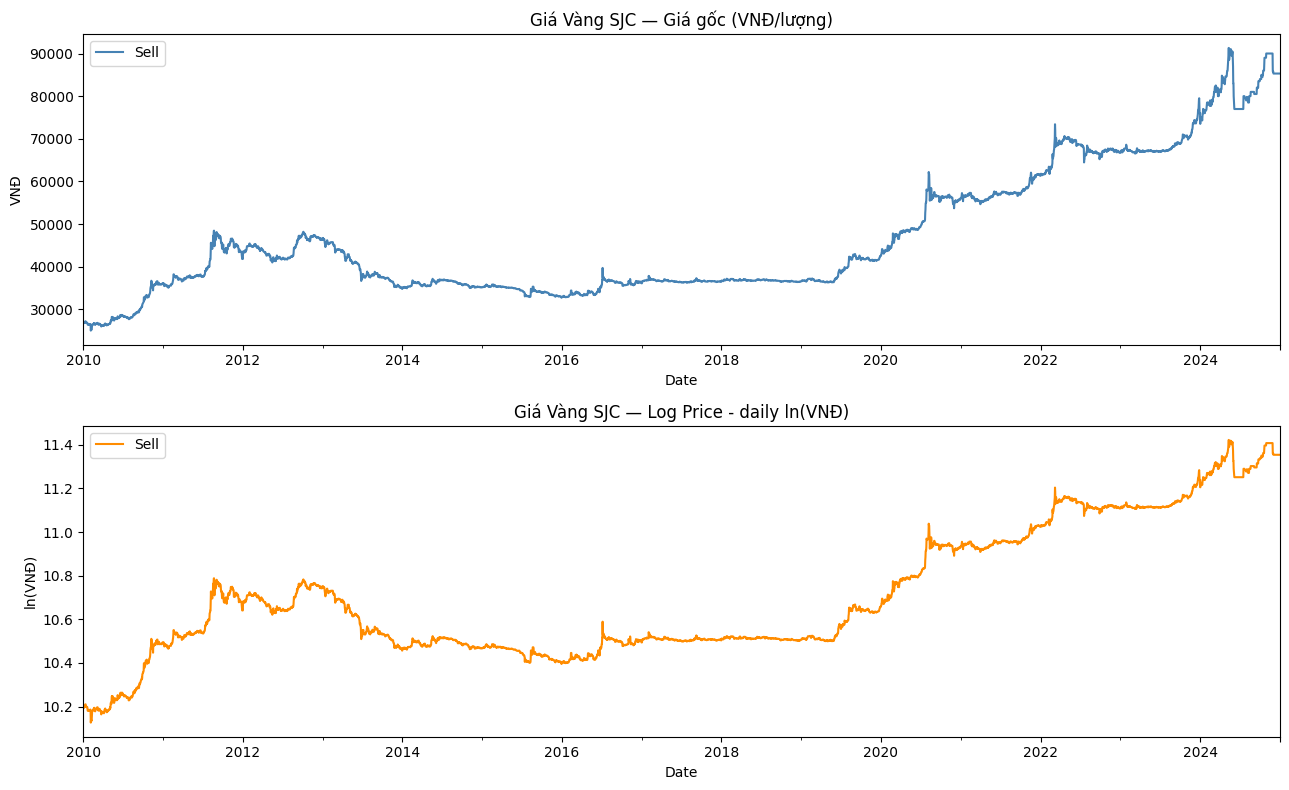

In [50]:
df = pd.read_excel('data/GoldSJC_2010_2025.xlsx', index_col='Date', parse_dates=True)
df = df[['Sell']].resample('D').ffill()  # Điền khoảng trống ngày nghỉ/lễ bằng forward-fill
df_log_daily = np.log(df)
df_log_monthly = df_log_daily.resample('ME').mean()


fig, axes = plt.subplots(2, 1, figsize=(13, 8))
df.plot(ax=axes[0], title='Giá Vàng SJC — Giá gốc (VNĐ/lượng)', color='steelblue')
axes[0].set_ylabel('VNĐ')
df_log_daily.plot(ax=axes[1], title='Giá Vàng SJC — Log Price - daily ln(VNĐ)', color='darkorange')
axes[1].set_ylabel('ln(VNĐ)')
plt.tight_layout()
plt.show()


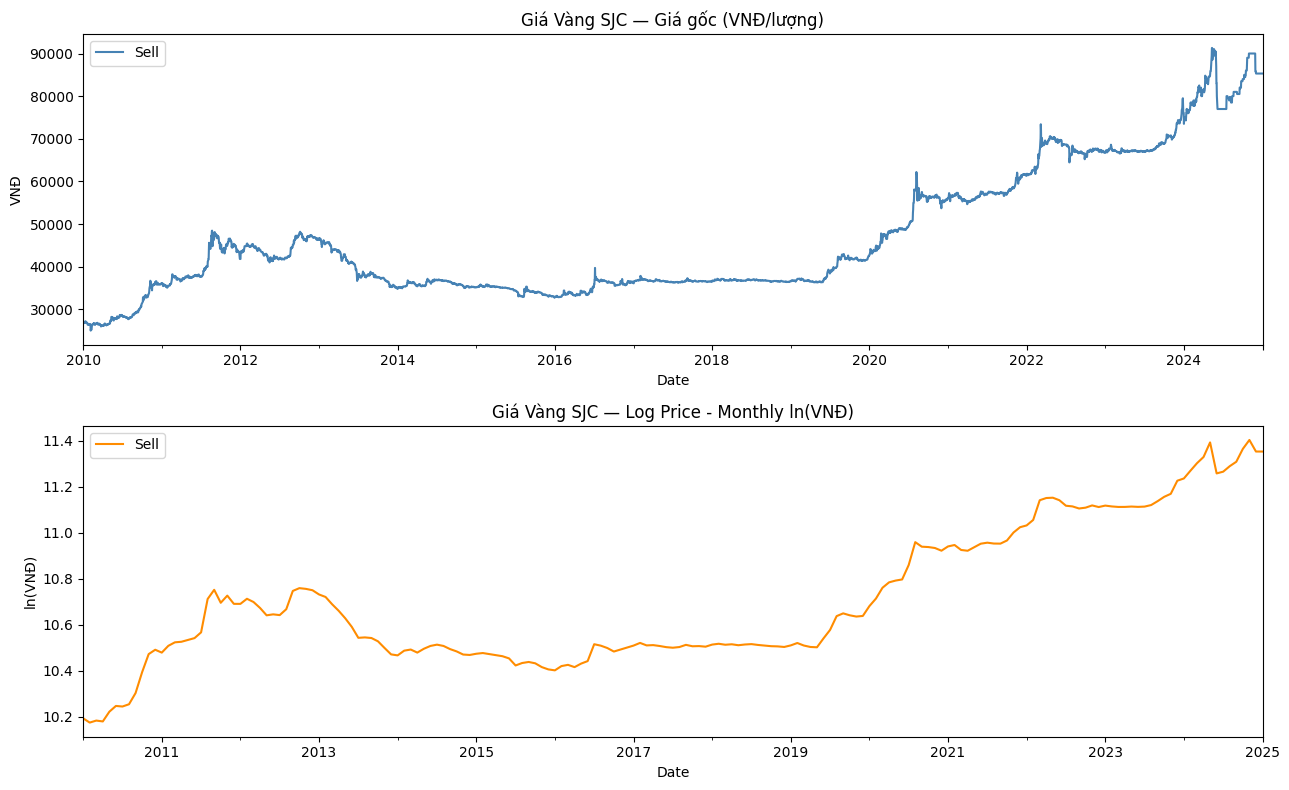

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
df.plot(ax=axes[0], title='Giá Vàng SJC — Giá gốc (VNĐ/lượng)', color='steelblue')
axes[0].set_ylabel('VNĐ')
df_log_monthly.plot(ax=axes[1], title='Giá Vàng SJC — Log Price - Monthly ln(VNĐ)', color='darkorange')
axes[1].set_ylabel('ln(VNĐ)')
plt.tight_layout()
plt.show()


In [52]:
print('=== Thông tin Dataset ===')
df.info()
print('\n=== Thống kê mô tả  (giá gốc VNĐ) ===')
print(df.describe())
print(f'\nNgày đầu  : {df.index[0].date()}')
print(f'Ngày cuối : {df.index[-1].date()}')
print(f'Tổng quan sát: {len(df)} ngày (calendar daily, ffill weekends/holidays)')


=== Thông tin Dataset ===
<class 'pandas.DataFrame'>
DatetimeIndex: 5480 entries, 2010-01-01 to 2025-01-01
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sell    5480 non-null   int64
dtypes: int64(1)
memory usage: 85.6 KB

=== Thống kê mô tả  (giá gốc VNĐ) ===
               Sell
count   5480.000000
mean   46605.620438
std    15180.874005
min    25000.000000
25%    36350.000000
50%    38500.000000
75%    56700.000000
max    91300.000000

Ngày đầu  : 2010-01-01
Ngày cuối : 2025-01-01
Tổng quan sát: 5480 ngày (calendar daily, ffill weekends/holidays)


## dùng Log Return (sai phân bậc 1 của logarit). Nó xấp xỉ bằng phần trăm thay đổi giá giữa các ngày/tháng ($P_t / P_{t-1} - 1$). Việc dùng Log Return giúp chuỗi dữ liệu có tính cộng gộp (additivity) và thường đưa chuỗi về trạng thái dừng (stationary).

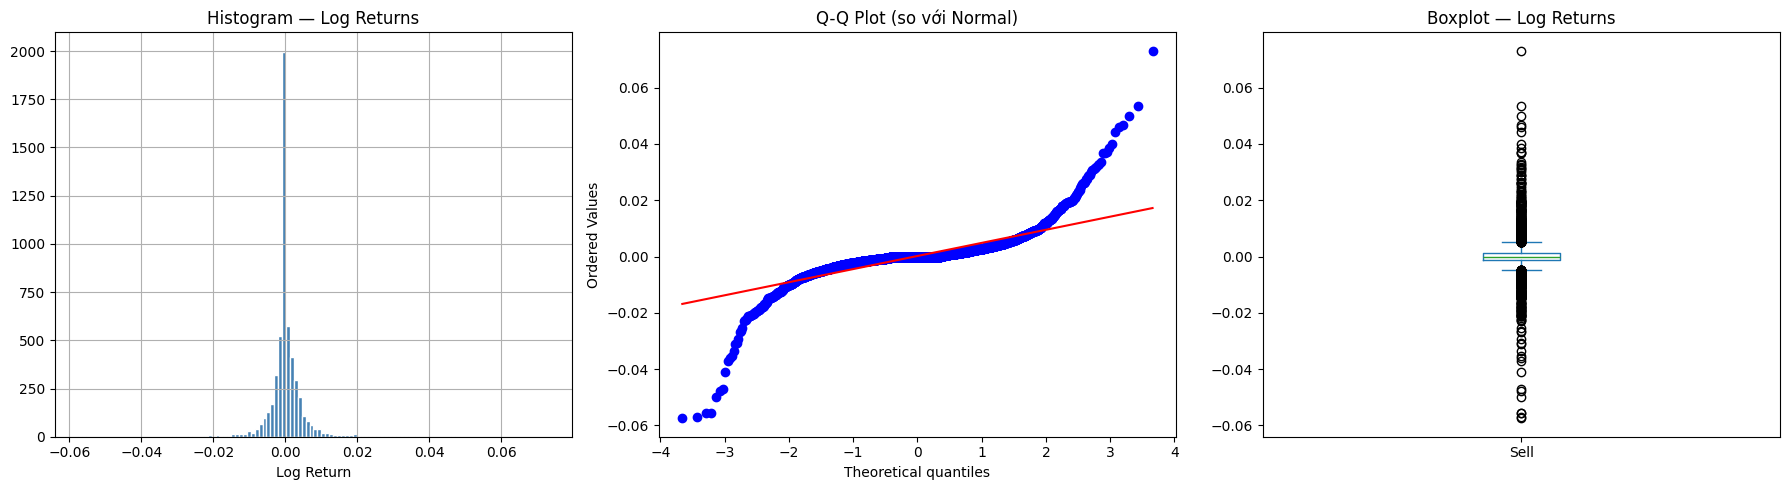

Skewness        : 0.3231
Excess Kurtosis : 29.0379  →  Heavy tails / Leptokurtic ⚠️
D'Agostino-Pearson: p = 0.000000  →  KHÔNG phân phối chuẩn ⚠️


In [53]:
# Phase 1b: Phân tích phân phối Log Returns & Heavy Tails 
log_returns =  df_log_daily['Sell'].diff().dropna() # (hôm nay tăng/giảm bao nhiêu triệu đồng so với hôm qua)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

log_returns.hist(bins=120, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Histogram — Log Returns')
axes[0].set_xlabel('Log Return')

stats.probplot(log_returns, plot=axes[1])
axes[1].set_title('Q-Q Plot (so với Normal)')

log_returns.plot(kind='box', ax=axes[2])
axes[2].set_title('Boxplot — Log Returns')

plt.tight_layout()
plt.show()

skew  = log_returns.skew()
kurt  = log_returns.kurtosis()  # excess kurtosis (normal = 0)
_, p_norm = stats.normaltest(log_returns)
print(f'Skewness        : {skew:.4f}')
print(f'Excess Kurtosis : {kurt:.4f}  →  {"Heavy tails / Leptokurtic ⚠️" if abs(kurt) > 1 else "Near-normal tails"}')
print(f"D'Agostino-Pearson: p = {p_norm:.6f}  →  {'KHÔNG phân phối chuẩn ⚠️' if p_norm < 0.05 else 'Phân phối chuẩn ✅'}")


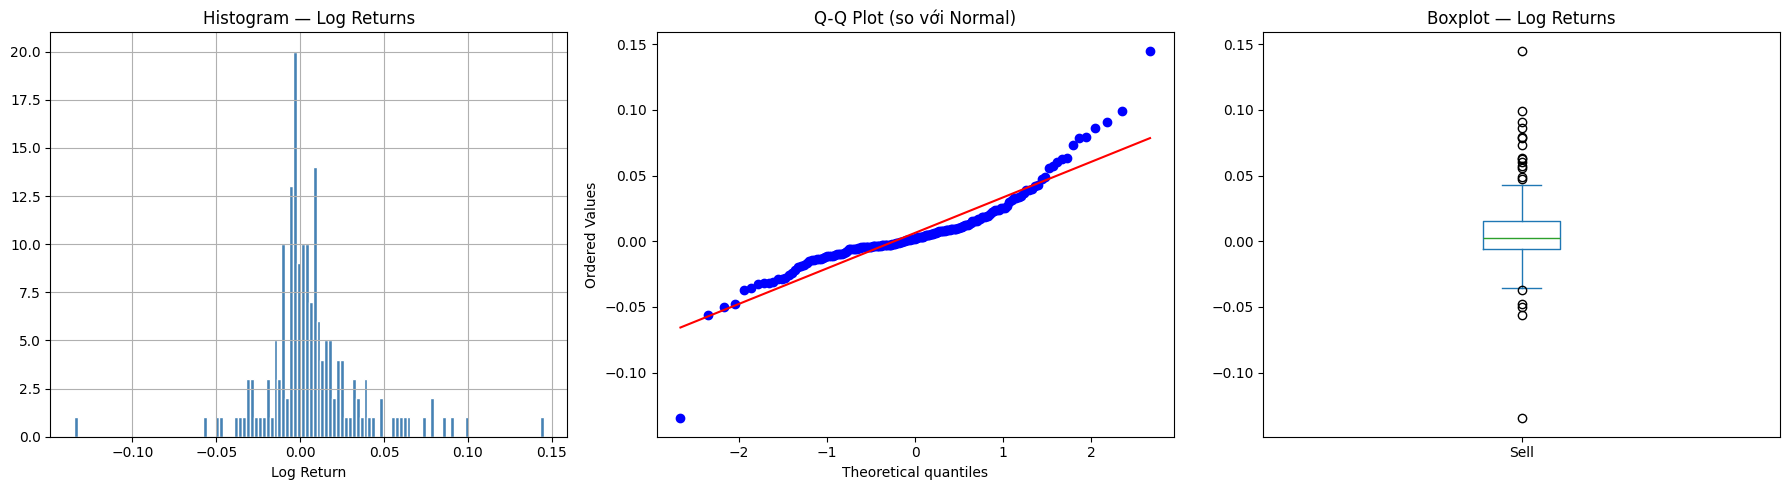

Skewness        : 0.6424
Excess Kurtosis : 6.3668  →  Heavy tails / Leptokurtic ⚠️
D'Agostino-Pearson: p = 0.000000  →  KHÔNG phân phối chuẩn ⚠️


In [54]:
# Phase 1b: Phân tích phân phối Log Returns & Heavy Tails 
log_returns =  df_log_monthly['Sell'].diff().dropna() # (hôm nay tăng/giảm bao nhiêu triệu đồng so với hôm qua)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

log_returns.hist(bins=120, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Histogram — Log Returns')
axes[0].set_xlabel('Log Return')

stats.probplot(log_returns, plot=axes[1])
axes[1].set_title('Q-Q Plot (so với Normal)')

log_returns.plot(kind='box', ax=axes[2])
axes[2].set_title('Boxplot — Log Returns')

plt.tight_layout()
plt.show()

skew  = log_returns.skew()
kurt  = log_returns.kurtosis()  # excess kurtosis (normal = 0)
_, p_norm = stats.normaltest(log_returns)
print(f'Skewness        : {skew:.4f}')
print(f'Excess Kurtosis : {kurt:.4f}  →  {"Heavy tails / Leptokurtic ⚠️" if abs(kurt) > 1 else "Near-normal tails"}')
print(f"D'Agostino-Pearson: p = {p_norm:.6f}  →  {'KHÔNG phân phối chuẩn ⚠️' if p_norm < 0.05 else 'Phân phối chuẩn ✅'}")


- Mức Kurtosis khổng lồ này khẳng định rằng: Giá vàng SJC cực kỳ dễ gặp những ngày biến động giá điên rồ (cực hạn) mà các mô hình thống kê truyền thống không thể lường trước được.
- p-value nhỏ tới mức máy tính làm tròn về 0. Điều này là bằng chứng thép (statistically significant) để bác bỏ hoàn toàn giả định rằng tỷ suất sinh lợi của vàng SJC tuân theo phân phối chuẩn.

## a) Phân rã dữ liệu (Decomposition) và Nhận xét

<Axes: title={'center': 'Residual'}, xlabel='Date'>

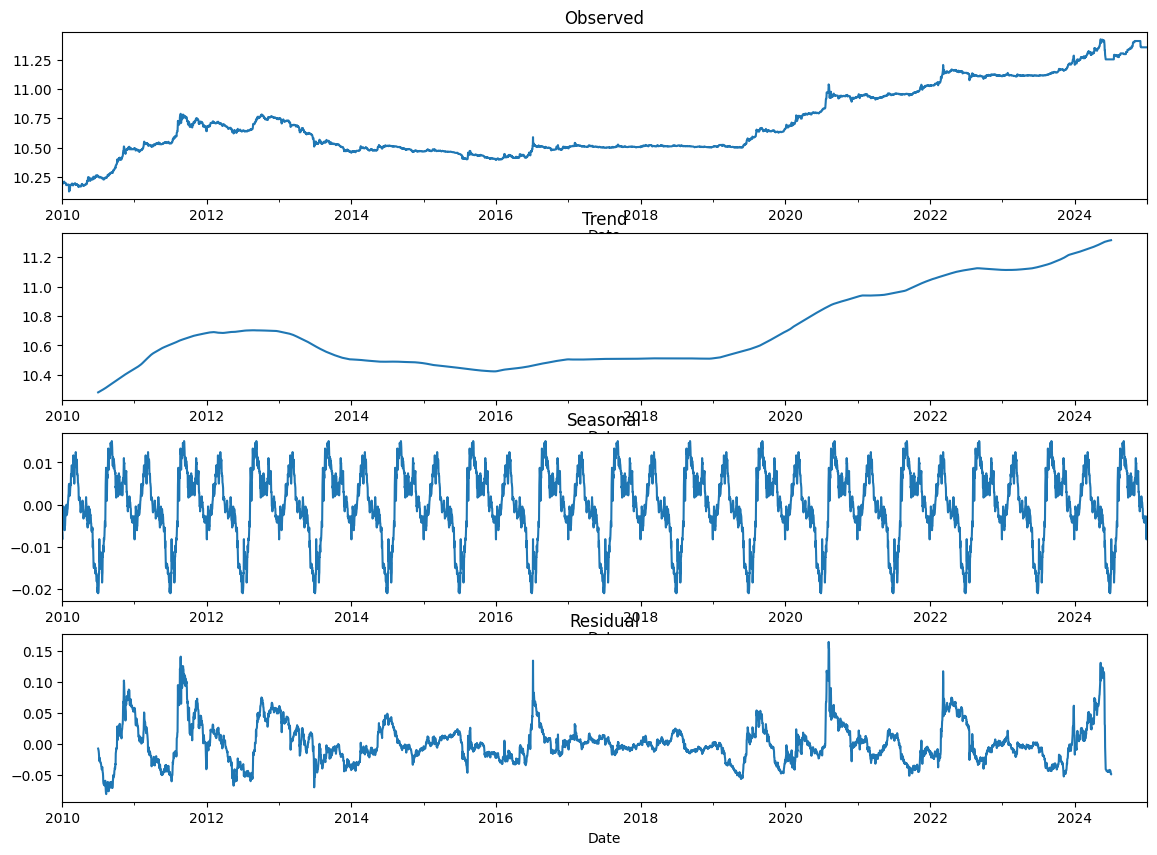

In [55]:
# period=252 cho trading days/năm, hoặc 12 cho monthly
result = seasonal_decompose(df_log_daily, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
result.observed.plot(ax=axes[0], title='Observed')
result.trend.plot(ax=axes[1],    title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3],   title='Residual')


<Axes: title={'center': 'Residual'}, xlabel='Date'>

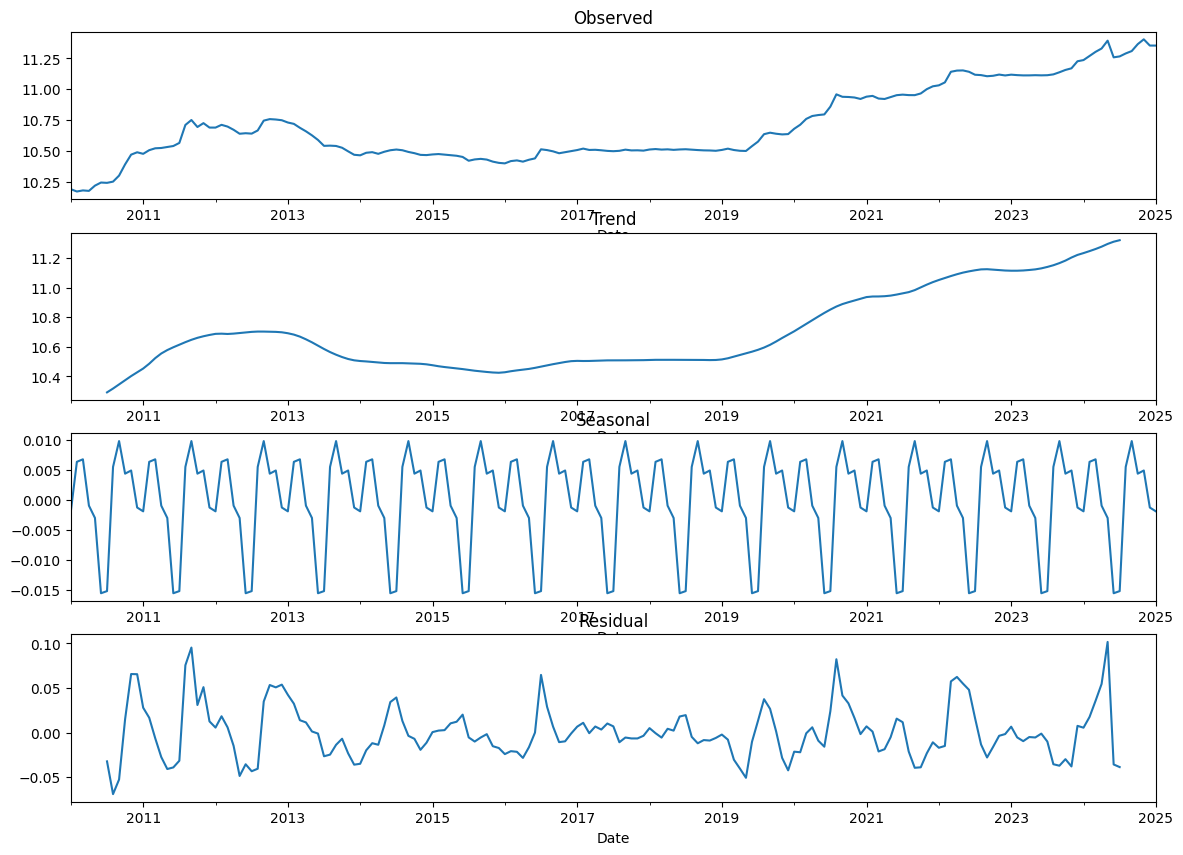

In [56]:
# period=252 cho trading days/năm, hoặc 12 cho monthly
result = seasonal_decompose(df_log_monthly, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
result.observed.plot(ax=axes[0], title='Observed')
result.trend.plot(ax=axes[1],    title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3],   title='Residual')


# Phân tích phân rã chuỗi thời gian (2010–2025)

Biểu đồ thể hiện **phân rã chuỗi thời gian** gồm 4 thành phần: Observed, Trend, Seasonal, và Residual.

## 1. Observed — Dữ liệu quan sát thực tế
Dữ liệu gốc từ 2010–2025 có xu hướng tăng dài hạn 

## 2. Trend — Xu hướng
Tăng nhẹ giai đoạn 2010–2012, đi ngang đến khoảng 2018, sau đó **tăng mạnh từ 2018–2025**.

## 3. Seasonal — Mùa vụ
Dao động đều đặn với biên độ **±0.01–0.02**, chu kỳ lặp lại ổn định tương ứng khoảng **6 tháng/chu kỳ**. 

## 4. Residual — Phần dư
Dao động trong khoảng **±0.05–0.15**. Một số đột biến lớn xuất hiện quanh các năm 2011, 2020, 2022 — nhiều khả năng phản ánh các **sự kiện bất thường** như khủng hoảng hoặc thay đổi chính sách đột ngột.

## Kết luận
Chuỗi dữ liệu bị chi phối chủ yếu bởi **xu hướng tăng dài hạn**. Thành phần mùa vụ có chu kỳ đều nhưng biên độ yếu, trong khi phần dư cho thấy một số cú sốc cần lưu ý khi dự báo.

## b) Kiểm định tính dừng và Tương quan

Fail to reject H0 → NON-STATIONARY ❌
ADF Test: ADF Statistic             -0.177076
p-value                    0.941200
Lags Used                 12.000000
Observations            5467.000000
Critical Value (1%)       -3.431547
Critical Value (5%)       -2.862069
Critical Value (10%)      -2.567051
dtype: float64
Reject H0 → NON-STATIONARY ❌

KPSS Test: KPSS Statistic            8.302877
p-value                   0.010000
Lags Used                44.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


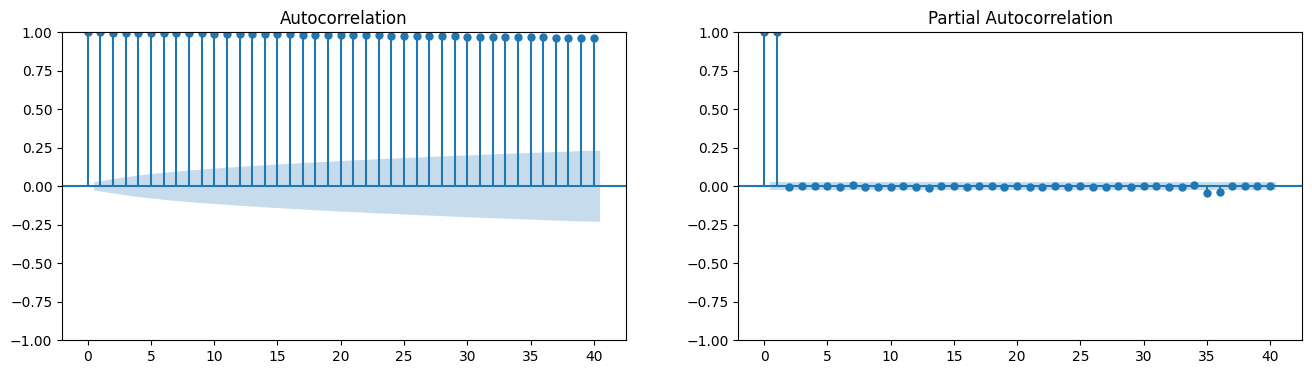

In [57]:
print("ADF Test:", adf_test(df_log_daily))
print("\nKPSS Test:", kpss_test(df_log_daily))

# ACF and PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_log_daily, ax=ax1, lags=40)
plot_pacf(df_log_daily, ax=ax2, lags=40)
plt.show()

Fail to reject H0 → NON-STATIONARY ❌
ADF Test: ADF Statistic            -0.450036
p-value                   0.901403
Lags Used                 1.000000
Observations            179.000000
Critical Value (1%)      -3.467420
Critical Value (5%)      -2.877826
Critical Value (10%)     -2.575452
dtype: float64
Reject H0 → NON-STATIONARY ❌

KPSS Test: KPSS Statistic           1.358351
p-value                  0.010000
Lags Used                9.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


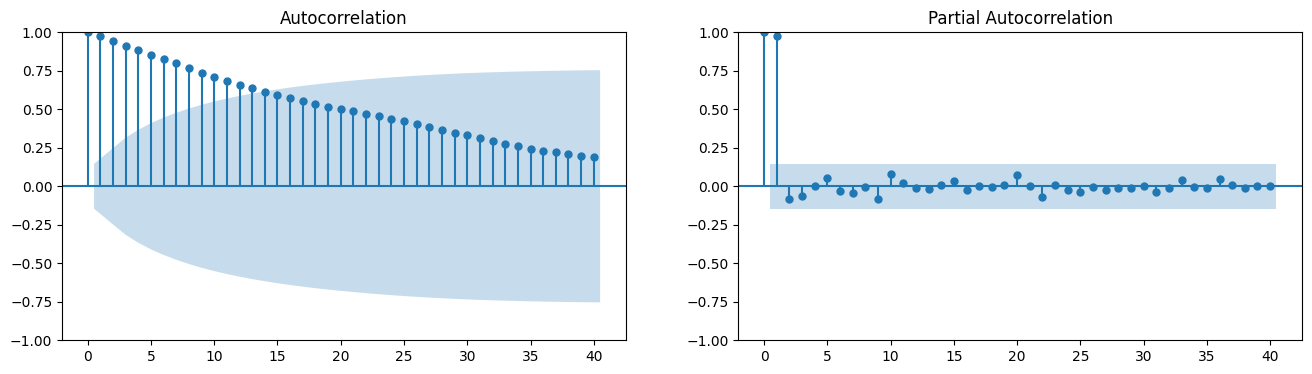

In [58]:
print("ADF Test:", adf_test(df_log_monthly))
print("\nKPSS Test:", kpss_test(df_log_monthly))

# ACF and PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_log_monthly, ax=ax1, lags=40)
plot_pacf(df_log_monthly, ax=ax2, lags=40)
plt.show()

=== Sau khi lấy sai phân bậc 1 (Log Returns) ===
ADF Test:
Reject H0 → STATIONARY ✅
ADF Statistic            -19.178828
p-value                    0.000000
Lags Used                 11.000000
Observations            5467.000000
Critical Value (1%)       -3.431547
Critical Value (5%)       -2.862069
Critical Value (10%)      -2.567051
dtype: float64

KPSS Test:
Fail to reject H0 → STATIONARY ✅
KPSS Statistic           0.275048
p-value                  0.100000
Lags Used                4.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


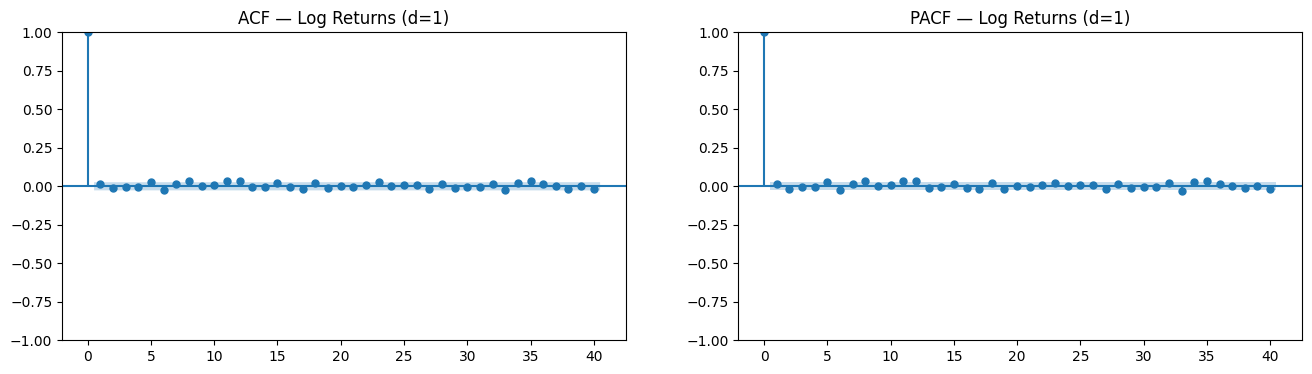

In [59]:
# Sai phân bậc 1 của Log Price = Log Returns: ln(Pt) - ln(Pt-1)
df_log_diff = df_log_daily.diff().dropna()

print('=== Sau khi lấy sai phân bậc 1 (Log Returns) ===')
print('ADF Test:')
print(adf_test(df_log_diff))
print('\nKPSS Test:')
print(kpss_test(df_log_diff))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_log_diff,  ax=ax1, lags=40, title='ACF — Log Returns (d=1)')
plot_pacf(df_log_diff, ax=ax2, lags=40, title='PACF — Log Returns (d=1)')
plt.show()


=== Sau khi lấy sai phân bậc 1 (Log Returns) ===
ADF Test:
Reject H0 → STATIONARY ✅
ADF Statistic          -1.019195e+01
p-value                 6.288488e-18
Lags Used               0.000000e+00
Observations            1.790000e+02
Critical Value (1%)    -3.467420e+00
Critical Value (5%)    -2.877826e+00
Critical Value (10%)   -2.575452e+00
dtype: float64

KPSS Test:
Fail to reject H0 → STATIONARY ✅
KPSS Statistic           0.212115
p-value                  0.100000
Lags Used                4.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


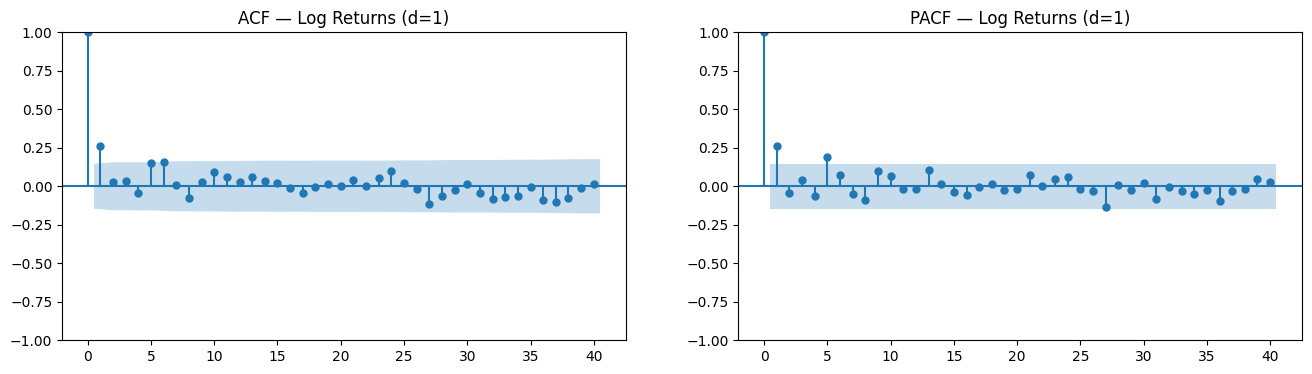

In [60]:
# Sai phân bậc 1 của Log Price = Log Returns: ln(Pt) - ln(Pt-1)
df_log_diff = df_log_monthly.diff().dropna()

print('=== Sau khi lấy sai phân bậc 1 (Log Returns) ===')
print('ADF Test:')
print(adf_test(df_log_diff))
print('\nKPSS Test:')
print(kpss_test(df_log_diff))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_log_diff,  ax=ax1, lags=40, title='ACF — Log Returns (d=1)')
plot_pacf(df_log_diff, ax=ax2, lags=40, title='PACF — Log Returns (d=1)')
plt.show()


# Ý Nghĩa Các Tham Số Trong Mô Mô Hình ARIMA $(p, d, q)$

Mô hình ARIMA được cấu thành từ ba tham số cơ bản: **p** (Auto Regressive), **d** (Integrated), và **q** (Moving Average). Dưới đây là ý nghĩa chi tiết của từng tham số:

---

### 🔹 Tham số $p$ (Bậc của thành phần Tự hồi quy - AR)
* **Định nghĩa:** $p$ là bậc của thuật ngữ Tự hồi quy (Auto Regressive). Nó đại diện cho số lượng khoảng trễ (lags) của biến mục tiêu $Y$ được sử dụng làm biến dự báo trong mô hình.
* **Bản chất:** Thuật ngữ "Tự hồi quy" trong ARIMA ám chỉ đây là một mô hình hồi quy tuyến tính sử dụng chính các giá trị trong quá khứ của nó để dự báo cho tương lai.

---

### 🔹 Tham số $d$ (Số lần lấy sai phân - I)
* **Bản chất của dữ liệu:** Các mô hình hồi quy tuyến tính hoạt động tốt nhất khi các biến dự báo không có sự tương quan và độc lập với nhau. Do đó, chúng ta cần phải biến đổi chuỗi thời gian về trạng thái **dừng (stationary)**.
* **Cách thực hiện:** Phương pháp phổ biến nhất để biến chuỗi thời gian thành chuỗi dừng là lấy sai phân (differencing) — tức là lấy giá trị hiện tại trừ đi giá trị ngay trước nó. Tùy thuộc vào độ phức tạp của chuỗi dữ liệu, bạn có thể cần phải lấy sai phân nhiều hơn một lần.
* **Định nghĩa:** Giá trị của $d$ là số lần lấy sai phân tối thiểu cần thiết để biến chuỗi thời gian thành chuỗi dừng. 
  * Nếu chuỗi thời gian vốn đã định sẵn là chuỗi dừng, thì $d = 0$.

---

### 🔹 Tham số $q$ (Bậc của thành phần Trung bình trượt - MA)
* **Định nghĩa:** $q$ là bậc của thuật ngữ Trung bình trượt (Moving Average). Nó đại diện cho số lượng sai số dự báo trong quá khứ (lagged forecast errors) được đưa vào mô hình ARIMA để điều chỉnh dự báo.


### 1. Xác định số hạng AR (p) qua biểu đồ PACF
* **Chức năng**: Xem biểu đồ PACF để xác định độ trễ cho các số hạng AR.
* **Khái niệm**: Tự tương quan riêng phần (PACF) là tương quan giữa chuỗi và độ trễ của nó.
* **Cơ chế**: Loại trừ các đóng góp từ các độ trễ trung gian.
* **Ý nghĩa**: Thể hiện mối tương quan thuần túy giữa độ trễ và chuỗi.
* **Mục đích**: Biết độ trễ đó có cần thiết trong số hạng AR hay không.

### 2. Xác định số hạng MA (q) qua biểu đồ ACF
* **Chức năng**: Xem xét biểu đồ ACF để xác định số hạng q.
* **Ý nghĩa**: ACF cho biết cần bao nhiêu thuật ngữ MA.
* **Mục đích**: Loại bỏ bất kỳ sự tự tương quan nào trong chuỗi dừng.


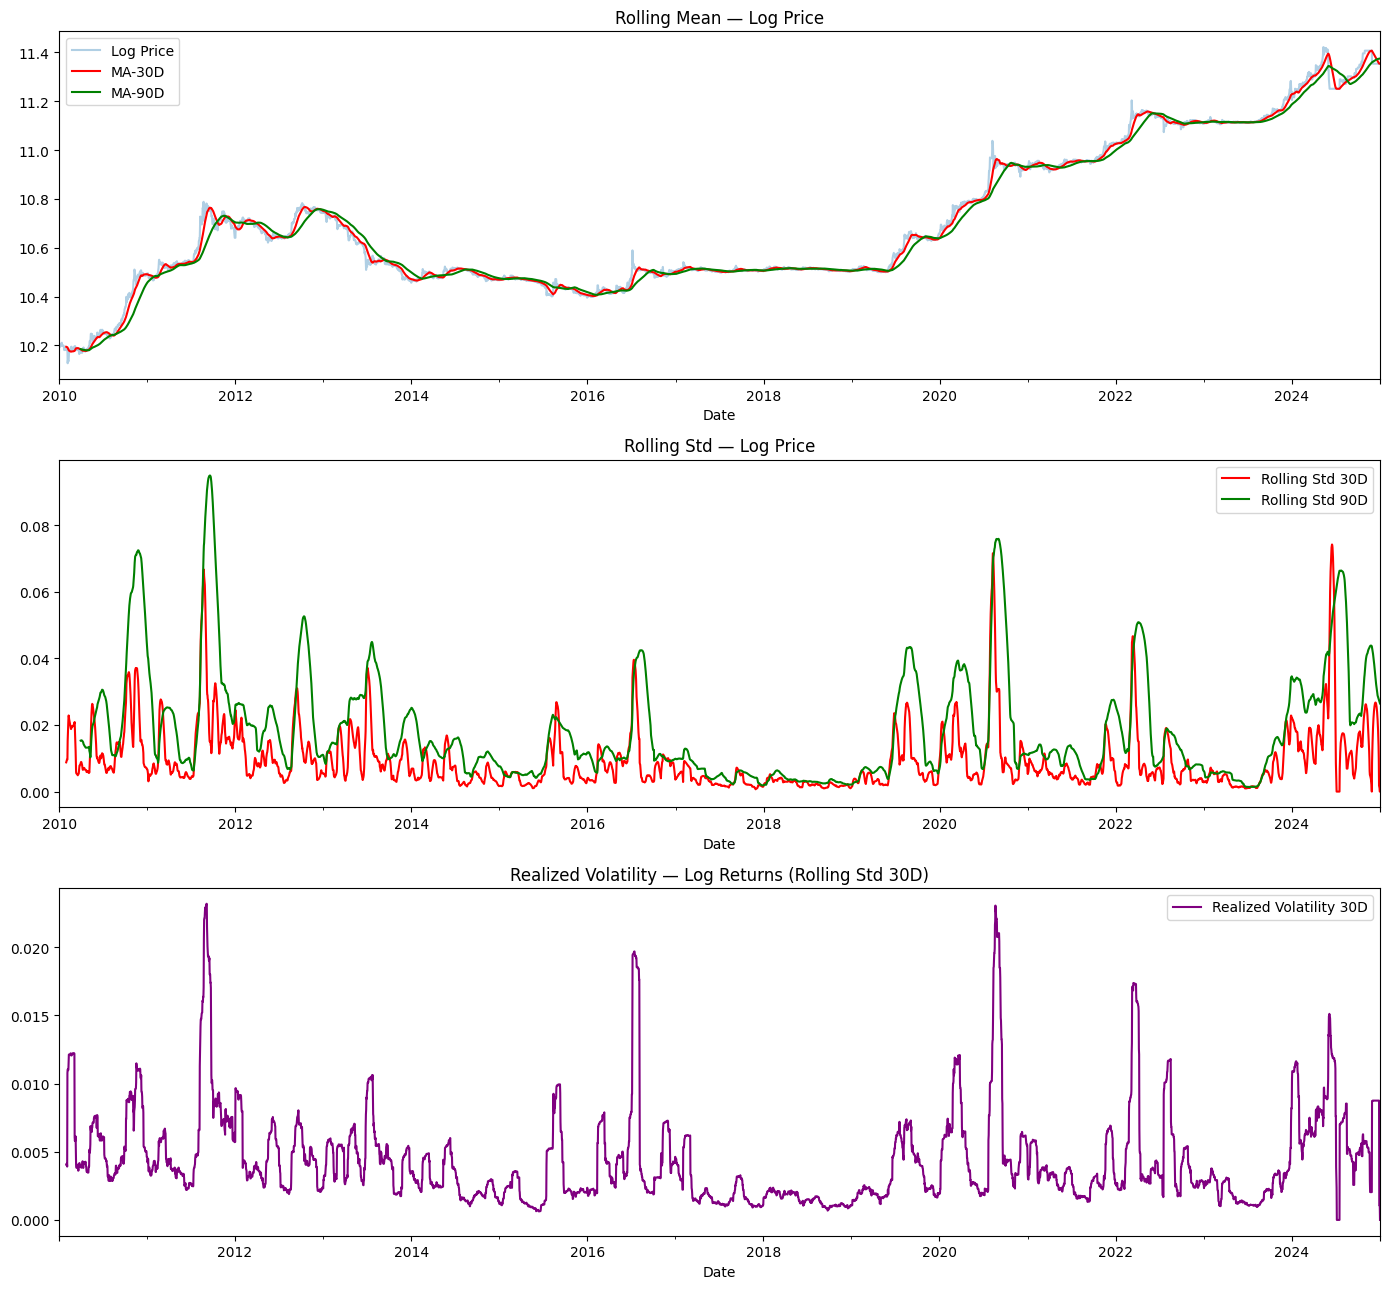

In [61]:
# Phase 2b: Rolling Statistics & Realized Volatility
log_ret = df_log_daily['Sell'].diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# Rolling mean trên log price
df_log_daily['Sell'].plot(ax=axes[0], alpha=0.35, label='Log Price')
df_log_daily['Sell'].rolling(30).mean().plot(ax=axes[0], label='MA-30D', color='red')
df_log_daily['Sell'].rolling(90).mean().plot(ax=axes[0], label='MA-90D', color='green')
axes[0].set_title('Rolling Mean — Log Price')
axes[0].legend()

# Rolling std (mức độ biến động của log price)
df_log_daily['Sell'].rolling(30).std().plot(ax=axes[1], label='Rolling Std 30D', color='red')
df_log_daily['Sell'].rolling(90).std().plot(ax=axes[1], label='Rolling Std 90D', color='green')
axes[1].set_title('Rolling Std — Log Price')
axes[1].legend()

# Realized volatility (rolling std of log returns)
log_ret.rolling(30).std().plot(ax=axes[2], label='Realized Volatility 30D', color='purple')
axes[2].set_title('Realized Volatility — Log Returns (Rolling Std 30D)')
axes[2].legend()

plt.tight_layout()
plt.show()


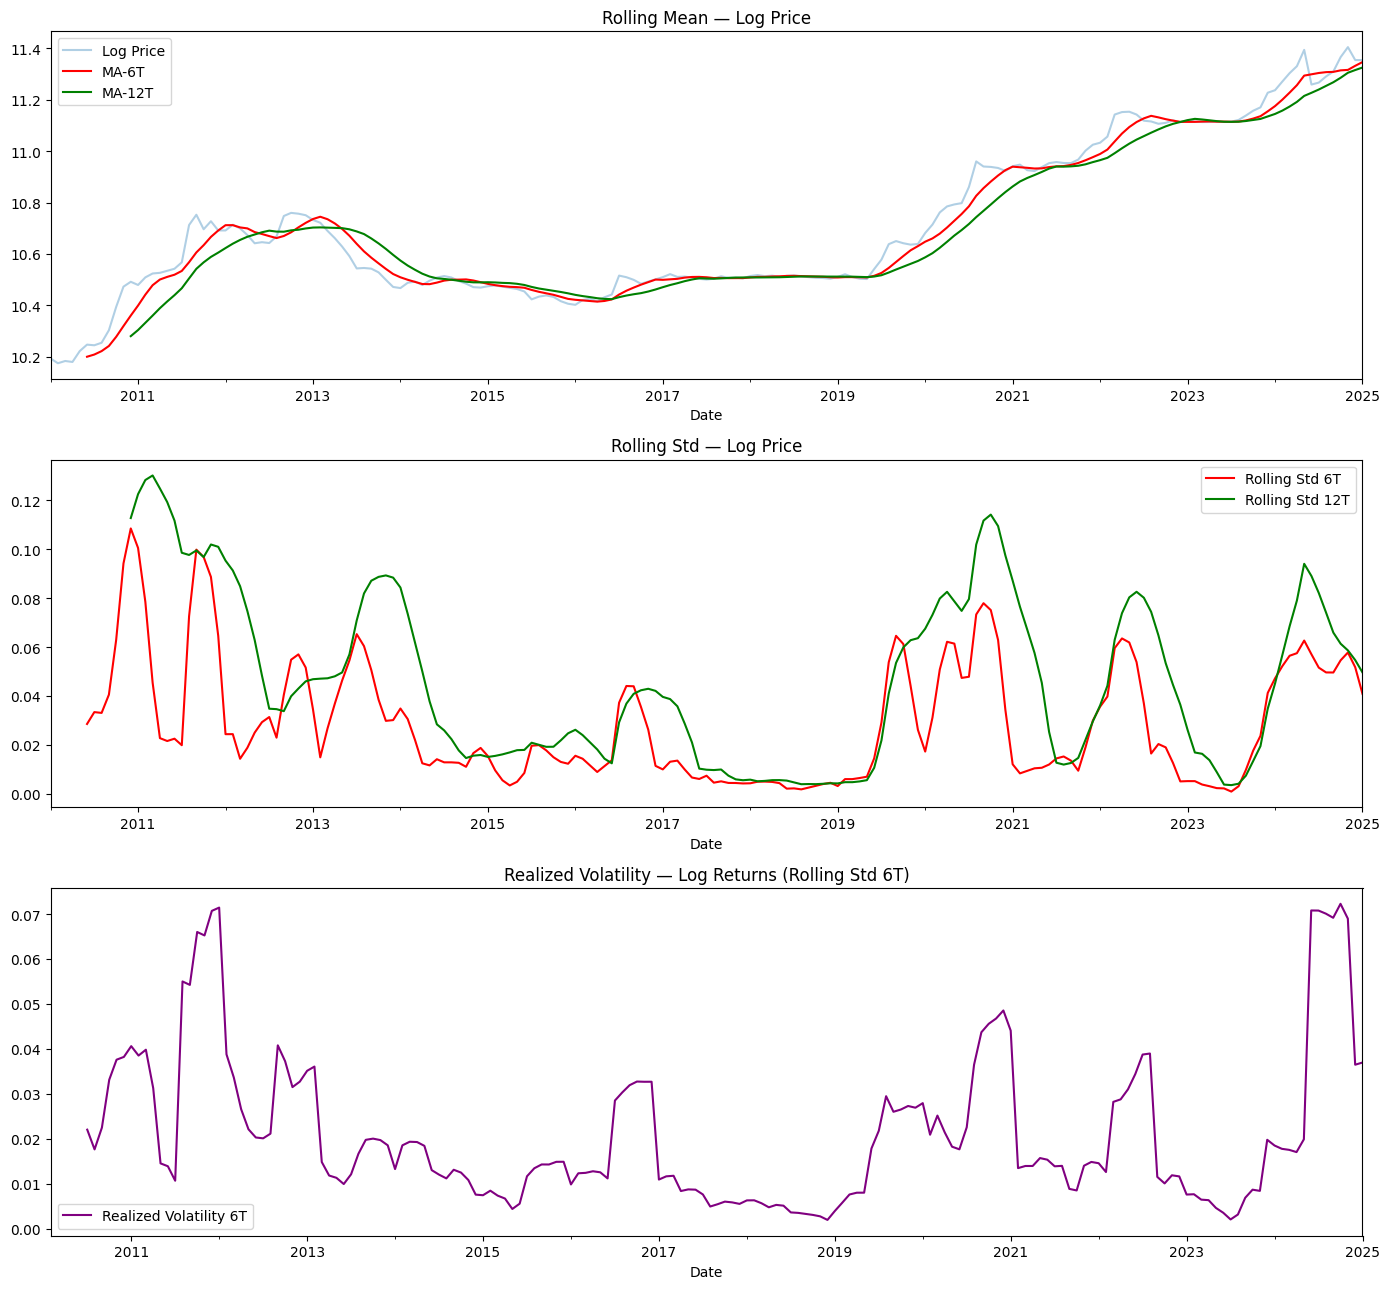

In [62]:
# Phase 2b: Rolling Statistics & Realized Volatility
log_ret = df_log_monthly['Sell'].diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# Rolling mean trên log price
df_log_monthly['Sell'].plot(ax=axes[0], alpha=0.35, label='Log Price')
df_log_monthly['Sell'].rolling(6).mean().plot(ax=axes[0], label='MA-6T', color='red')
df_log_monthly['Sell'].rolling(12).mean().plot(ax=axes[0], label='MA-12T', color='green')
axes[0].set_title('Rolling Mean — Log Price')
axes[0].legend()

# Rolling std (mức độ biến động của log price)
df_log_monthly['Sell'].rolling(6).std().plot(ax=axes[1], label='Rolling Std 6T', color='red')
df_log_monthly['Sell'].rolling(12).std().plot(ax=axes[1], label='Rolling Std 12T', color='green')
axes[1].set_title('Rolling Std — Log Price')
axes[1].legend()

# Realized volatility (rolling std of log returns)
log_ret.rolling(6).std().plot(ax=axes[2], label='Realized Volatility 6T', color='purple')
axes[2].set_title('Realized Volatility — Log Returns (Rolling Std 6T)')
axes[2].legend()

plt.tight_layout()
plt.show()


**Nhận xét Phase 2:**
- ADF reject H0 → Log Price NON-stationary; Log Returns STATIONARY → **d = 1** là đủ.
- ACF/PACF của Log Returns cut-off gần ngay lag 1 → ARIMA với p, q nhỏ.
- Realized Volatility không đồng đều qua thời gian → dấu hiệu ARCH effect

---
## Phase 4 — Exploratory Modeling: ARIMA

Dùng **giá gốc (VNĐ)** để metrics (MAE/RMSE/MAPE) diễn giải được trực tiếp. Bậc d=1 đã xác nhận từ Phase 2.


## c) Fit mô hình ARIMA (80% Train), Đánh giá và Dự báo tương lai

In [63]:
# Chia train/test 80/20 — dùng giá gốc VNĐ (không dùng df_log)
train_size = int(len(df_log_daily) * 0.8)
train_daily = df_log_daily['Sell'][:train_size]
test_daily  = df_log_daily['Sell'][train_size:]
print(f'Train: {len(train_daily)} ngày  ({train_daily.index[0].date()} → {train_daily.index[-1].date()})')
print(f'Test : {len(test_daily)}  ngày  ({test_daily.index[0].date()}  → {test_daily.index[-1].date()})')


Train: 4384 ngày  (2010-01-01 → 2022-01-01)
Test : 1096  ngày  (2022-01-02  → 2025-01-01)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-33282.061, Time=0.19 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-33280.511, Time=0.28 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-33280.521, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-33278.704, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-33278.004, Time=0.51 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 1.512 seconds

✅ Best order (AIC): ARIMA(0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4384
Model:               SARIMAX(0, 1, 0)   Log Likelihood               16643.031
Date:                Thu, 25 Jun 2026   AIC                         -33282.061
Time:                        01:07:27   BIC                         -33269.290
Sample:                    01-01-2010   HQIC                        -33277.555
                         - 01-

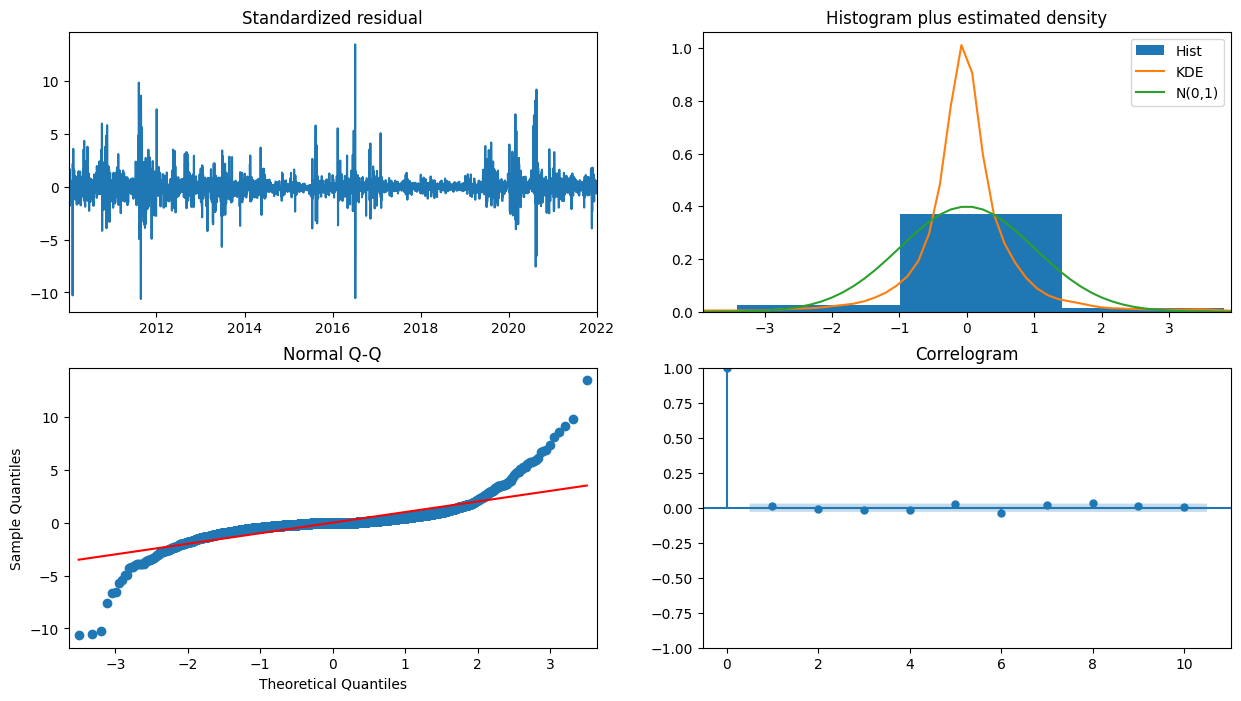

In [64]:
# auto_arima: tìm best (p, d, q) theo AIC; d=1 cố định từ kết quả Phase 2
stepwise_model = auto_arima(
    train_daily,
    start_p=0, start_q=0,
    max_p=5,   max_q=5,
    d=1,                        # d=1 đã xác nhận từ ADF test
    seasonal=False,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    information_criterion='aic'
)
best_order = stepwise_model.order
print(f'\n✅ Best order (AIC): ARIMA{best_order}')
print(stepwise_model.summary())
stepwise_model.plot_diagnostics(figsize=(15, 8))
plt.show()


In [65]:
# best_order = (1,1,1) 

In [66]:

# Fit ARIMA voi trend 
model_arima  = ARIMA(train_daily, order=best_order, trend='t')
fitted_arima = model_arima.fit()
print(fitted_arima.summary())


                               SARIMAX Results                                
Dep. Variable:                   Sell   No. Observations:                 4384
Model:                 ARIMA(0, 1, 0)   Log Likelihood               16643.025
Date:                Thu, 25 Jun 2026   AIC                         -33282.050
Time:                        01:07:28   BIC                         -33269.279
Sample:                    01-01-2010   HQIC                        -33277.544
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0002   8.32e-05      2.221      0.026    2.17e-05       0.000
sigma2      2.941e-05   1.59e-07    184.512      0.000    2.91e-05    2.97e-05
Ljung-Box (L1) (Q):                   0.45   Jarque-

   MAE  : 4,723.17
   RMSE : 6,498.86
   MAPE : 6.04%


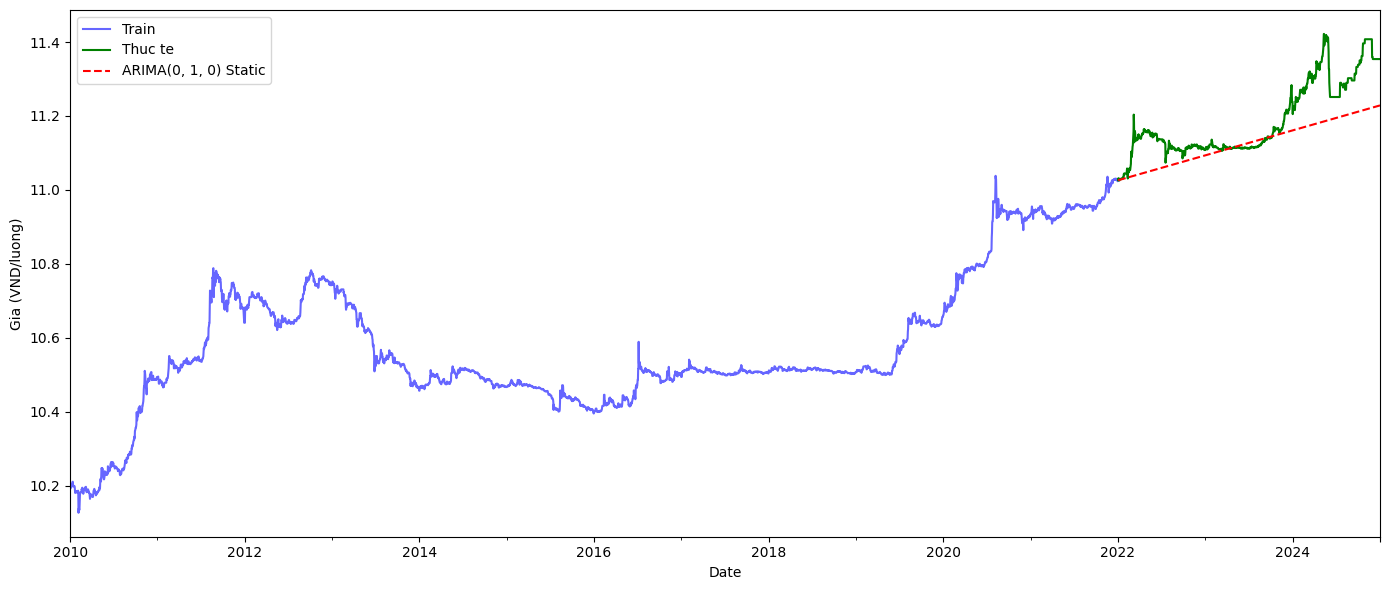

In [67]:

# Static forecast
forecast_arima = fitted_arima.forecast(steps=len(test_daily))
forecast_arima.index = test_daily.index

forecast_vnd = np.exp(forecast_arima)
test_vnd = np.exp(test_daily)
train_vnd = np.exp(train_daily) # Phục hồi luôn tập train để vẽ biểu đồ cho đồng nhất

mae_arima_static  = mean_absolute_error(test_vnd, forecast_vnd)
rmse_arima_static = np.sqrt(mean_squared_error(test_vnd, forecast_vnd))
mape_arima_static = np.mean(np.abs((test_vnd - forecast_vnd) / test_vnd)) * 100

print(f'   MAE  : {mae_arima_static:,.2f}')
print(f'   RMSE : {rmse_arima_static:,.2f}')
print(f'   MAPE : {mape_arima_static:.2f}%')

plt.figure(figsize=(14, 6))
train_daily.plot(label='Train', color='blue', alpha=0.6)
test_daily.plot(label='Thuc te', color='green')
forecast_arima.plot(label=f'ARIMA{best_order} Static', color='red', linestyle='--')

plt.xlabel('Date')
plt.ylabel('Gia (VND/luong)')
plt.legend()
plt.tight_layout()
plt.show()


## d) Expanding Window và Sliding Window

### 🔄 Chiến Lược Khối Cấu Trúc Dữ Liệu: Expanding Window vs Sliding Window

`Expanding` và `Sliding` là 2 phương pháp **"nạp kiến thức"** (huấn luyện và cập nhật mô hình) khác nhau khi thực hiện kiểm định kiểm chứng (backtesting) chuỗi thời gian:

* **Expanding Window (Học sinh nhớ dai):**
  * **Cơ chế:** Ngày nào cũng học thêm kiến thức mới, đồng thời ghi nhớ toàn bộ dữ liệu từ ngày đầu tiên cho đến thời điểm hiện tại.
  * **Triết lý:** Tin rằng lịch sử càng dài thì nền tảng mô hình càng vững chắc và đáng tin cậy.
* **Sliding Window (Học sinh cuốn chiếu):**
  * **Cơ chế:** Ngày nào cũng học kiến thức mới, nhưng bộ nhớ chỉ giữ lại một khoảng thời gian cố định (ví dụ: đúng 365 ngày gần nhất), các dữ liệu xa hơn sẽ bị xóa sạch.
  * **Triết lý:** Tin rằng thế giới và thị trường thay đổi liên tục, những câu chuyện của 2–3 năm trước không còn giá trị tham chiếu cho ngày mai nữa.

---

📌 **Mục đích thử nghiệm:** Việc chạy song song cả 2 chiến lược này là để xác định xem với bộ dữ liệu cụ thể của bạn (ví dụ: giá vàng), thị trường đang thiên về xu hướng **"nhớ dai"** (bị ảnh hưởng bởi lịch sử dài hạn) hay **"mau quên"** (chỉ phản ứng với các biến động ngắn hạn).


In [68]:
close = df_log_daily['Sell'].values      # dùng giá gốc (df['Sell']), không phải df_log
train_size = int(len(close) * 0.8)

# ══════════════════════════════════════════════════════════════
# KỸ THUẬT 1: EXPANDING WINDOW
# Fit 1 lần trên train; mỗi bước append observation mới với
# refit=False → cập nhật state, KHÔNG ước lượng lại tham số
# Nhanh hơn ~1000x so với refit toàn bộ từ đầu mỗi bước
# ══════════════════════════════════════════════════════════════
print('Expanding Window đang chạy...')
expanding_preds = []

fitted_exp = ARIMA(close[:train_size], order=best_order, trend='t').fit()
for i in range(train_size, len(close)):
    pred = fitted_exp.forecast(steps=1)[0]
    expanding_preds.append(pred)
    fitted_exp = fitted_exp.append([close[i]], refit=False)
    if (i - train_size) % 200 == 0:
        print(f'   Bước {i - train_size}/{len(close) - train_size}')
print('   Xong ✅')


Expanding Window đang chạy...
   Bước 0/1096
   Bước 200/1096
   Bước 400/1096
   Bước 600/1096
   Bước 800/1096
   Bước 1000/1096
   Xong ✅



Sliding Window đang chạy...
   Bước 0/1096
   Bước 200/1096
   Bước 400/1096
   Bước 600/1096
   Bước 800/1096
   Bước 1000/1096
   Xong ✅


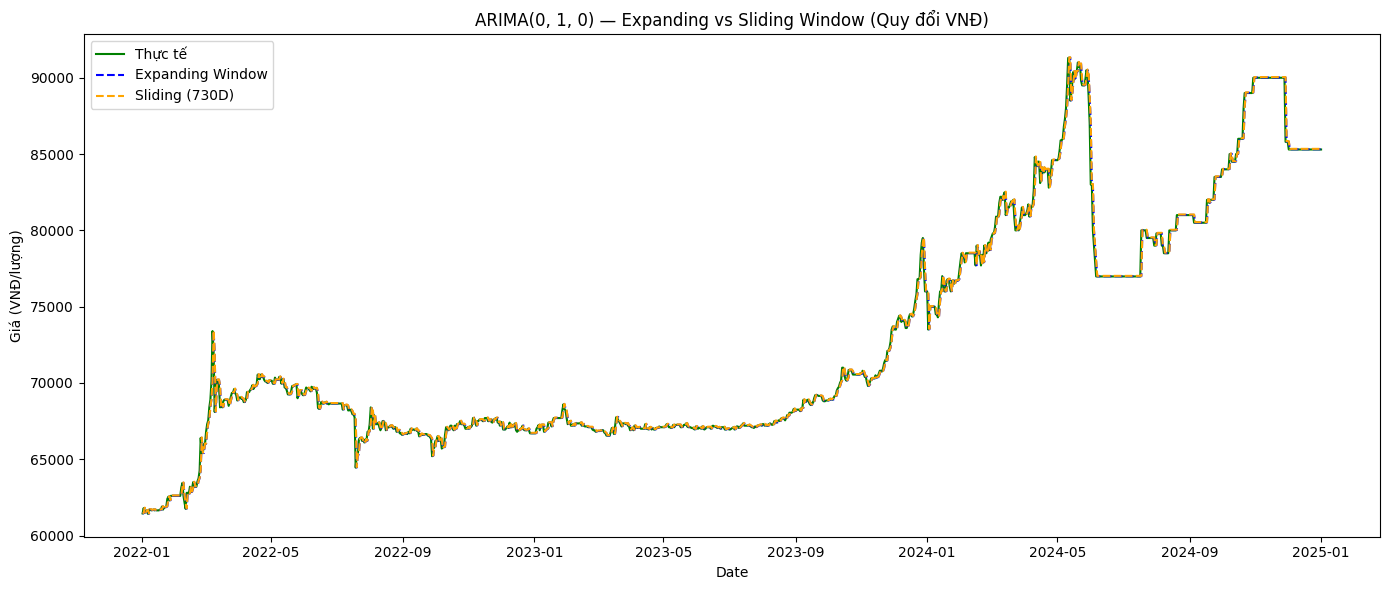


Phương pháp                     MAE       RMSE     MAPE
ARIMA Static                  4,723      6,499    6.04%
Expanding Window                210        466    0.28%
Sliding (730D)                  219        466    0.30%


In [69]:
# ══════════════════════════════════════════════════════════════
# KỸ THUẬT 2: SLIDING WINDOW
# Fit 1 lần trên cửa sổ đầu tiên; mỗi bước apply sang cửa
# sổ mới với refit=False → giữ nguyên tham số, cập nhật state
# ══════════════════════════════════════════════════════════════
print('\nSliding Window đang chạy...')
sliding_preds = []
window_size   = 365 * 2  # 2 năm calendar

# Vẫn fit mô hình bằng dữ liệu log (close)
fitted_sld = ARIMA(
    close[train_size - window_size:train_size],
    order=best_order, trend='t'
).fit()

for i in range(train_size, len(close)):
    pred = fitted_sld.forecast(steps=1)[0] # Trả ra giá trị dạng log
    sliding_preds.append(pred)
    new_window = close[max(0, i - window_size + 1):i + 1]
    fitted_sld = fitted_sld.apply(new_window, refit=False)
    if (i - train_size) % 200 == 0:
        print(f'   Bước {i - train_size}/{len(close) - train_size}')
print('   Xong ✅')

# ── Bước Thêm Mới: Chuyển đổi toàn bộ về giá gốc (VNĐ) ───────
actual_log = close[train_size:]
dates      = df.index[train_size:]

# Dùng np.exp() đảo ngược giá trị
actual_vnd          = np.exp(actual_log)
sliding_preds_vnd   = np.exp(sliding_preds)
expanding_preds_vnd = np.exp(expanding_preds) # Giả định biến này đã được chạy ở trên

def get_metrics(act, pred):
    mae  = mean_absolute_error(act, pred)
    rmse = np.sqrt(mean_squared_error(act, pred))
    mape = np.mean(np.abs((act - pred) / act)) * 100
    return mae, rmse, mape

# Tính metrics dựa trên mảng VNĐ
mae_exp, rmse_exp, mape_exp = get_metrics(actual_vnd, expanding_preds_vnd)
mae_sld, rmse_sld, mape_sld = get_metrics(actual_vnd, sliding_preds_vnd)

# ── Biểu đồ ──────────────────────────────────────────────────
plt.figure(figsize=(14, 6))
# Plot trực tiếp bằng mảng VNĐ
plt.plot(dates, actual_vnd,          label='Thực tế',          color='green')
plt.plot(dates, expanding_preds_vnd, label='Expanding Window', color='blue',   linestyle='--')
plt.plot(dates, sliding_preds_vnd,   label='Sliding (730D)',   color='orange', linestyle='--')

plt.title(f'ARIMA{best_order} — Expanding vs Sliding Window (Quy đổi VNĐ)')
plt.xlabel('Date')
plt.ylabel('Giá (VNĐ/lượng)')
plt.legend()
plt.tight_layout()
plt.show()

# ── Bảng so sánh ─────────────────────────────────────────────
print('\n' + '='*62)
print(f'{"Phương pháp":<24} {"MAE":>10} {"RMSE":>10} {"MAPE":>8}')
print('='*62)
# Biến mae_arima_static được tính ở phần Static Forecast trước đó cũng đã quy đổi VNĐ
print(f'{"ARIMA Static":<24} {mae_arima_static:>10,.0f} {rmse_arima_static:>10,.0f} {mape_arima_static:>7.2f}%')
print(f'{"Expanding Window":<24} {mae_exp:>10,.0f} {rmse_exp:>10,.0f} {mape_exp:>7.2f}%')
print(f'{"Sliding (730D)":<24} {mae_sld:>10,.0f} {rmse_sld:>10,.0f} {mape_sld:>7.2f}%')
print('='*62)

**Nhận xét — Expanding vs Sliding Window:**
- **Expanding Window**: tận dụng toàn bộ lịch sử, phù hợp khi cấu trúc thị trường ổn định.
- **Sliding (730D)**: chỉ dùng 2 năm gần nhất, thích nghi tốt hơn khi có thay đổi cấu trúc.

---
## Phase 5 — Residual Diagnostics
Kiểm tra phần dư ARIMA: autocorrelation (Ljung-Box), heteroskedasticity (ARCH test), phân phối.




###  Trực Quan Hóa Phần Dư (Visual Diagnostics)
Mục đích: Vẽ ra **5 biểu đồ** để đánh giá phần dư bằng mắt thường.

* **Residuals theo thời gian (Line plot):**
  * Kiểm tra sai số có dao động đều quanh mức 0 hay không.
  * Nếu biên độ dao động lúc to lúc nhỏ, dữ liệu có thể bị phương sai thay đổi (*heteroskedasticity*).
* **Histogram:**
  * Xem xét phân phối của phần dư có hình chuông (chuẩn) không.
* **ACF & PACF:**
  * Kiểm tra tự tương quan.
  * Nếu các cột (lags) vượt ra khỏi vùng xanh (vùng tin cậy) $\rightarrow$ Các sai số vẫn có mối liên hệ trong quá khứ (mô hình chưa tốt).
* **Q-Q Plot:**
  * So sánh phân phối của phần dư với phân phối chuẩn.
  * Các điểm nằm sát đường chéo màu đỏ $\rightarrow$ Phần dư tuân theo phân phối chuẩn.



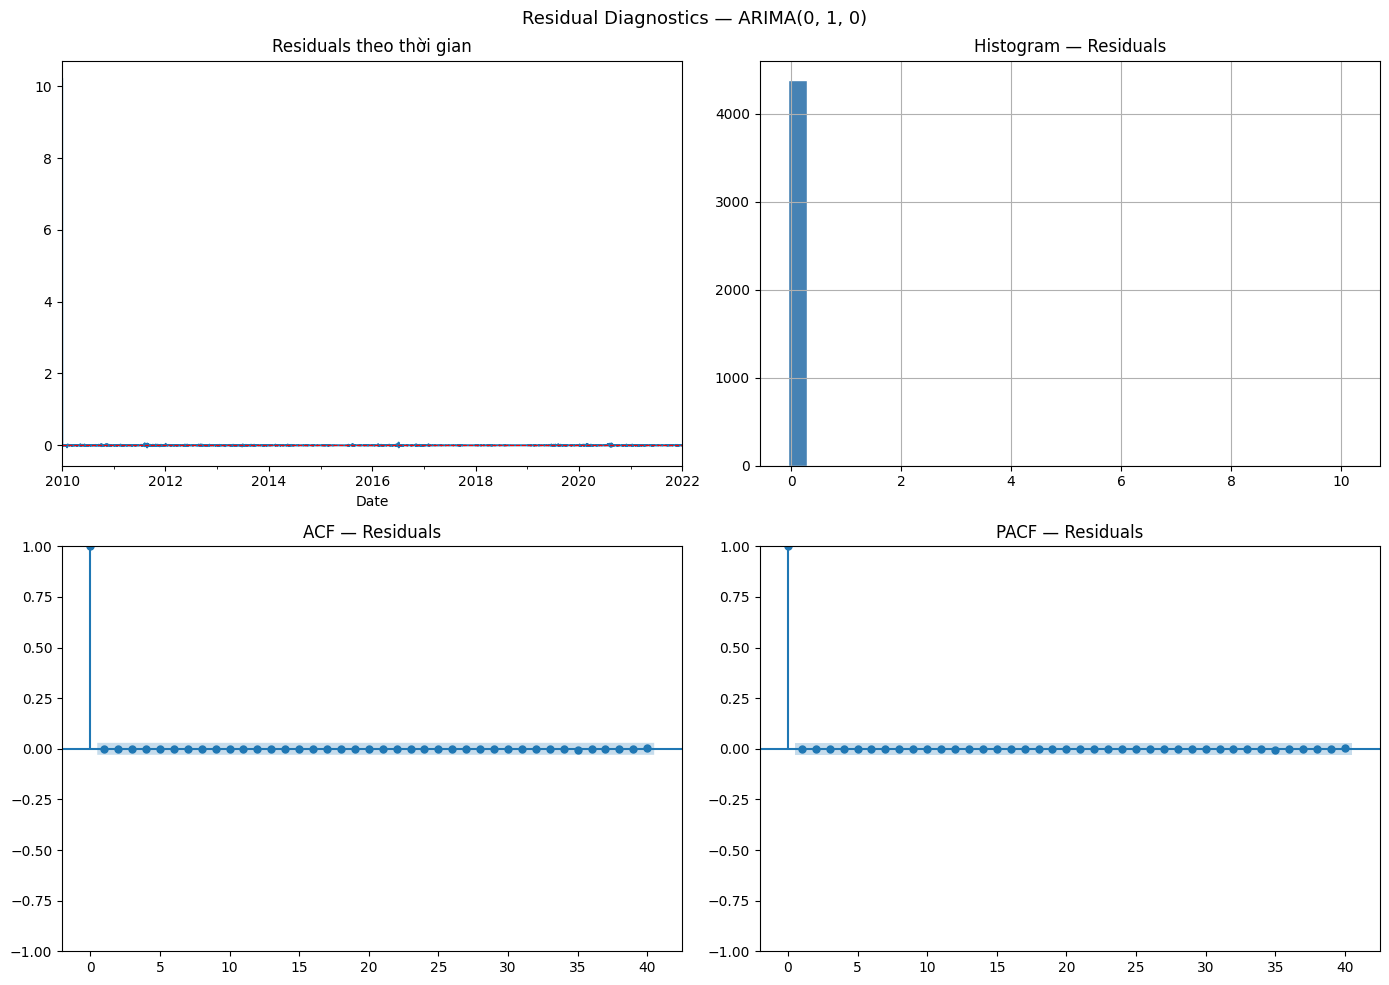

=== Ljung-Box Test — ARIMA(0, 1, 0) ===
     lb_stat  lb_pvalue
10  0.008542        1.0
20  0.015680        1.0
30  0.019883        1.0

→ Phần dư là white noise ✅



In [70]:
# Phase 5a: Kiểm tra phần dư ARIMA — biểu đồ tổng quan
residuals = pd.Series(fitted_arima.resid.values, index=train_daily.index)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

residuals.plot(ax=axes[0, 0], title='Residuals theo thời gian')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=0.8)

residuals.hist(bins=30, ax=axes[0, 1], color='steelblue', edgecolor='white')
axes[0, 1].set_title('Histogram — Residuals')

plot_acf(residuals,  ax=axes[1, 0], lags=40, title='ACF — Residuals')
plot_pacf(residuals, ax=axes[1, 1], lags=40, title='PACF — Residuals')

plt.suptitle(f'Residual Diagnostics — ARIMA{best_order}', fontsize=13)
plt.tight_layout()
plt.show()




lb = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print(f'=== Ljung-Box Test — ARIMA{best_order} ===')
print(lb.to_string())
print(f'\n→ {"Phần dư là white noise ✅" if (lb["lb_pvalue"] > 0.05).all() else "Còn autocorrelation trong phần dư ⚠️ — xem lại order"}')

print()


## SARIMA

In [71]:
# --- IMPORT THÊM CÁC THƯ VIỆN CẦN THIẾT ---
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt



train_size_m = int(len(df_log_monthly) * 0.8)
train_m = df_log_monthly['Sell'][:train_size_m]
test_m  = df_log_monthly['Sell'][train_size_m:]


In [72]:

print(f'Train (Tháng): {len(train_m)} tháng  ({train_m.index[0].date()} → {train_m.index[-1].date()})')
print(f'Test  (Tháng): {len(test_m)}  tháng  ({test_m.index[0].date()}  → {test_m.index[-1].date()})\n')


Train (Tháng): 144 tháng  (2010-01-31 → 2021-12-31)
Test  (Tháng): 37  tháng  (2022-01-31  → 2025-01-31)



In [73]:

print("--- Đang huấn luyện SARIMA (m=6) ---")
sarima_model = auto_arima(
    train_m,
    seasonal=True,
    m=6,
    d=1, D=1,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)


--- Đang huấn luyện SARIMA (m=6) ---
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[6]             : AIC=inf, Time=0.41 sec
 ARIMA(0,1,0)(0,1,0)[6]             : AIC=-530.684, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[6]             : AIC=-572.468, Time=0.06 sec
 ARIMA(0,1,1)(0,1,1)[6]             : AIC=-604.707, Time=0.15 sec
 ARIMA(0,1,1)(0,1,0)[6]             : AIC=-543.158, Time=0.03 sec
 ARIMA(0,1,1)(1,1,1)[6]             : AIC=-602.987, Time=0.20 sec
 ARIMA(0,1,1)(0,1,2)[6]             : AIC=-602.998, Time=0.35 sec
 ARIMA(0,1,1)(1,1,0)[6]             : AIC=-573.540, Time=0.07 sec
 ARIMA(0,1,1)(1,1,2)[6]             : AIC=-600.916, Time=0.39 sec
 ARIMA(0,1,0)(0,1,1)[6]             : AIC=-582.169, Time=0.11 sec
 ARIMA(1,1,1)(0,1,1)[6]             : AIC=-603.422, Time=0.20 sec
 ARIMA(0,1,2)(0,1,1)[6]             : AIC=-603.171, Time=0.22 sec
 ARIMA(1,1,0)(0,1,1)[6]             : AIC=-604.761, Time=0.12 sec
 ARIMA(1,1,0)(0,1,0)[6]             : AIC=-545.209, Time=0.03 sec
 

In [74]:
print(sarima_model.summary())
sarima_order          = sarima_model.order
sarima_seasonal_order = sarima_model.seasonal_order
sarima_forecast       = sarima_model.predict(n_periods=len(test_m))


                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 6)   Log Likelihood                 305.381
Date:                             Thu, 25 Jun 2026   AIC                           -604.761
Time:                                     01:07:54   BIC                           -596.001
Sample:                                 01-31-2010   HQIC                          -601.201
                                      - 12-31-2021                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4100      0.057      7.195      0.000       0.298       0.522
ma.S.L6       -0.8644      

### 1. Cấu hình tham số mô hình Holt-Winters
* **Xu hướng (Trend)**: Chọn `trend='add'` (Xu hướng dạng Cộng).
* **Mùa vụ (Seasonal)**: Chọn `seasonal='add'` (Mùa vụ dạng Cộng).
* **Cơ sở lựa chọn**: Dựa vào biểu đồ *Seasonal Decompose* và đặc điểm phân phối dữ liệu qua các năm.

### 2. Phân biệt các dạng thành phần Mùa vụ (Seasonal)

#### 📌 Dạng Cộng – Additive (`seasonal='add'`)
* **Biên độ**: Giữ nguyên một mức tuyệt đối cố định theo thời gian.
* **Đặc điểm**: Độ cao của đỉnh và độ sâu của đáy không thay đổi.
* **Quan hệ**: Không phụ thuộc vào giá trị chuỗi đang cao hay thấp.

#### 📌 Dạng Nhân – Multiplicative (`seasonal='mul'`)
* **Biên độ**: Tỷ lệ thuận với giá trị tổng thể của chuỗi.
* **Khi chuỗi tăng**: Các sóng mùa vụ sẽ phình to ra.
* **Khi chuỗi giảm**: Các sóng mùa vụ sẽ thu hẹp lại.


In [75]:
print("\n--- Huấn luyện Holt-Winters (chu kỳ 12) ---")
hw_model = ExponentialSmoothing(
    train_m,
    trend='add',
    seasonal='add',
    seasonal_periods=6
).fit()
hw_forecast = hw_model.forecast(steps=len(test_m))



--- Huấn luyện Holt-Winters (chu kỳ 12) ---



=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===
Mô hình                       MAE       RMSE     MAPE
------------------------------------------------------
SARIMA Static                   0          0    0.45%
Holt-Winters Static             0          0    1.00%


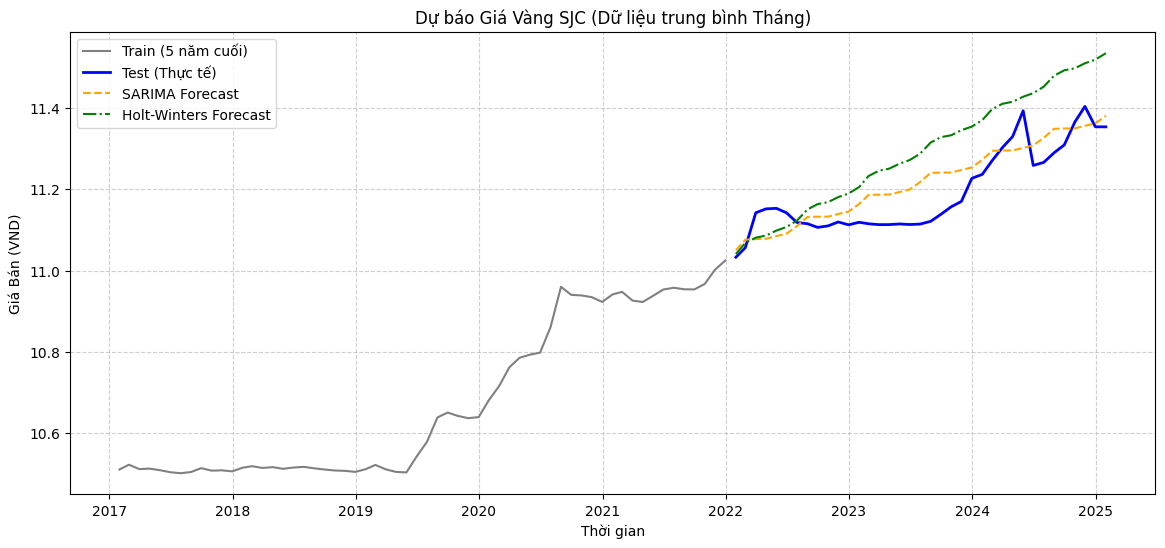

In [76]:

print("\n=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===")
mae_s, rmse_s, mape_s = get_metrics(test_m.values, np.array(sarima_forecast))
mae_h, rmse_h, mape_h = get_metrics(test_m.values, hw_forecast.values)
print(f'{"Mô hình":<22} {"MAE":>10} {"RMSE":>10} {"MAPE":>8}')
print('-'*54)
print(f'{"SARIMA Static":<22} {mae_s:>10,.0f} {rmse_s:>10,.0f} {mape_s:>7.2f}%')
print(f'{"Holt-Winters Static":<22} {mae_h:>10,.0f} {rmse_h:>10,.0f} {mape_h:>7.2f}%')

plt.figure(figsize=(14, 6))
plt.plot(train_m.index[-60:], train_m.values[-60:], label='Train (5 năm cuối)', color='gray')
plt.plot(test_m.index, test_m.values, label='Test (Thực tế)', color='blue', linewidth=2)
plt.plot(test_m.index, sarima_forecast, label='SARIMA Forecast', color='orange', linestyle='--')
plt.plot(test_m.index, hw_forecast, label='Holt-Winters Forecast', color='green', linestyle='-.')
plt.title('Dự báo Giá Vàng SJC (Dữ liệu trung bình Tháng)')
plt.xlabel('Thời gian')
plt.ylabel('Giá Bán (VND)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Sliding Window (24 tháng) đang chạy cho SARIMA và Holt-Winters...
   Bước 0/37
   Bước 10/37
   Bước 20/37
   Bước 30/37
   Xong ✅

Mô hình                                 MAE       RMSE     MAPE
SARIMA Static                             0          0    0.45%
SARIMA Sliding (24T)                      0          0    0.21%
--------------------------------------------------------------------
Holt-Winters Static                       0          0    1.00%
Holt-Winters Sliding (24T)                0          0    0.24%


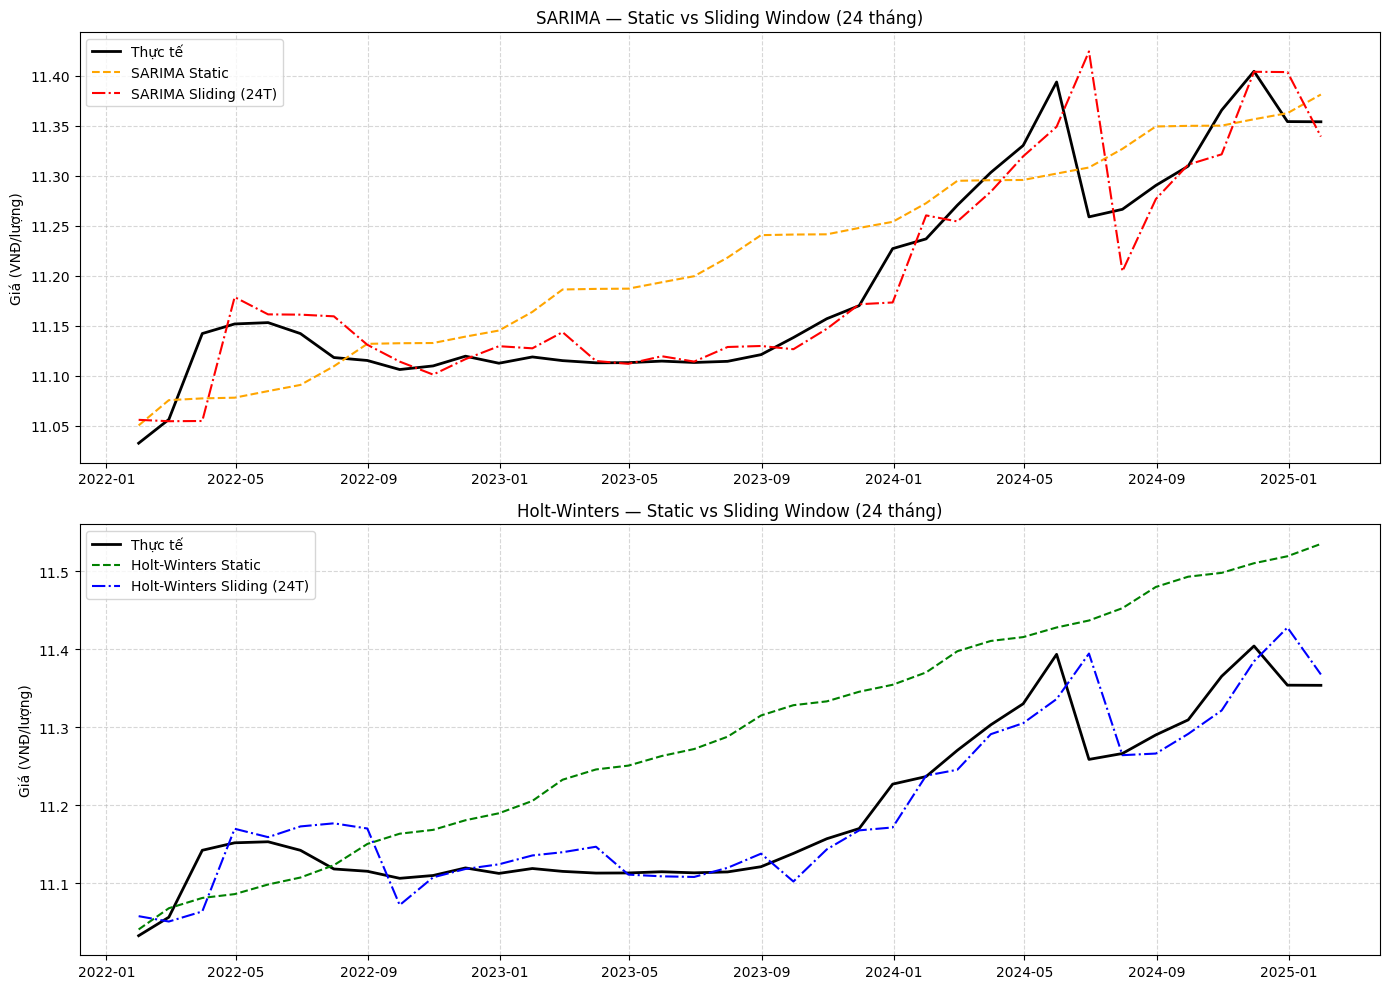

In [77]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

# ── Dữ liệu monthly & tham số cửa sổ ──────────────────────────────────────
monthly_vals  = df_log_monthly['Sell'].values   # 181 tháng
train_size_m  = 144                         # cùng điểm split với static (Jan 2022)
window_size_m = 48                   # 24 tháng = 2 năm

# ── Khởi tạo SARIMAX trên cửa sổ đầu tiên [120:144] ─────────────────
fitted_sarima_sw = SARIMAX(
    monthly_vals[train_size_m - window_size_m : train_size_m],
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# ── Vòng lặp Sliding Window ───────────────────────────────────────
print('Sliding Window (24 tháng) đang chạy cho SARIMA và Holt-Winters...')
sliding_preds_sarima_sw = []
sliding_preds_hw_sw     = []

for i in range(train_size_m, len(monthly_vals)):
    window = monthly_vals[i - window_size_m : i]

    fitted_sarima_sw = fitted_sarima_sw.apply(window, refit=False)
    sliding_preds_sarima_sw.append(fitted_sarima_sw.forecast(steps=1)[0])

    hw_sw = ExponentialSmoothing(
        window,
        trend='add',
        seasonal='add',
        seasonal_periods=12,
        initialization_method='estimated'
    ).fit()
    sliding_preds_hw_sw.append(float(hw_sw.forecast(steps=1)[0]))

    if (i - train_size_m) % 10 == 0:
        print(f'   Bước {i - train_size_m}/{len(monthly_vals) - train_size_m}')

print('   Xong ✅\n')

# ── Metrics ─────────────────────────────────────────────────────
actual_m = monthly_vals[train_size_m:]

mae_sarima_sw, rmse_sarima_sw, mape_sarima_sw = get_metrics(actual_m, sliding_preds_sarima_sw)
mae_hw_sw,     rmse_hw_sw,     mape_hw_sw     = get_metrics(actual_m, sliding_preds_hw_sw)

mae_sarima_st, rmse_sarima_st, mape_sarima_st = get_metrics(test_m.values, np.array(sarima_forecast))
mae_hw_st,     rmse_hw_st,     mape_hw_st     = get_metrics(test_m.values, hw_forecast.values)

# ── Bảng so sánh ────────────────────────────────────────────────────
print('='*68)
print(f'{"Mô hình":<32} {"MAE":>10} {"RMSE":>10} {"MAPE":>8}')
print('='*68)
print(f'{"SARIMA Static":<32} {mae_sarima_st:>10,.0f} {rmse_sarima_st:>10,.0f} {mape_sarima_st:>7.2f}%')
print(f'{"SARIMA Sliding (24T)":<32} {mae_sarima_sw:>10,.0f} {rmse_sarima_sw:>10,.0f} {mape_sarima_sw:>7.2f}%')
print('-'*68)
print(f'{"Holt-Winters Static":<32} {mae_hw_st:>10,.0f} {rmse_hw_st:>10,.0f} {mape_hw_st:>7.2f}%')
print(f'{"Holt-Winters Sliding (24T)":<32} {mae_hw_sw:>10,.0f} {rmse_hw_sw:>10,.0f} {mape_hw_sw:>7.2f}%')
print('='*68)

# ── Biểu đồ ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(test_m.index, test_m.values,            label='Thực tế',              color='black',  linewidth=2)
axes[0].plot(test_m.index, sarima_forecast,           label='SARIMA Static',        color='orange', linestyle='--')
axes[0].plot(test_m.index, sliding_preds_sarima_sw,   label='SARIMA Sliding (24T)', color='red',    linestyle='-.')
axes[0].set_title('SARIMA — Static vs Sliding Window (24 tháng)')
axes[0].set_ylabel('Giá (VNĐ/lượng)')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(test_m.index, test_m.values,            label='Thực tế',                   color='black', linewidth=2)
axes[1].plot(test_m.index, hw_forecast.values,       label='Holt-Winters Static',        color='green', linestyle='--')
axes[1].plot(test_m.index, sliding_preds_hw_sw,      label='Holt-Winters Sliding (24T)', color='blue',  linestyle='-.')
axes[1].set_title('Holt-Winters — Static vs Sliding Window (24 tháng)')
axes[1].set_ylabel('Giá (VNĐ/lượng)')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Expanding Window đang chạy cho SARIMA và Holt-Winters...
   Bước 0/37
   Bước 10/37
   Bước 20/37
   Bước 30/37
   Xong ✅

Mô hình                                    MAE       RMSE     MAPE
SARIMA Static                                0          0    0.45%
SARIMA Sliding (48T)                         0          0    0.21%
SARIMA Expanding                             0          0    0.20%
------------------------------------------------------------------------
Holt-Winters Static                          0          0    1.00%
Holt-Winters Sliding (48T)                   0          0    0.24%
Holt-Winters Expanding                       0          0    0.20%


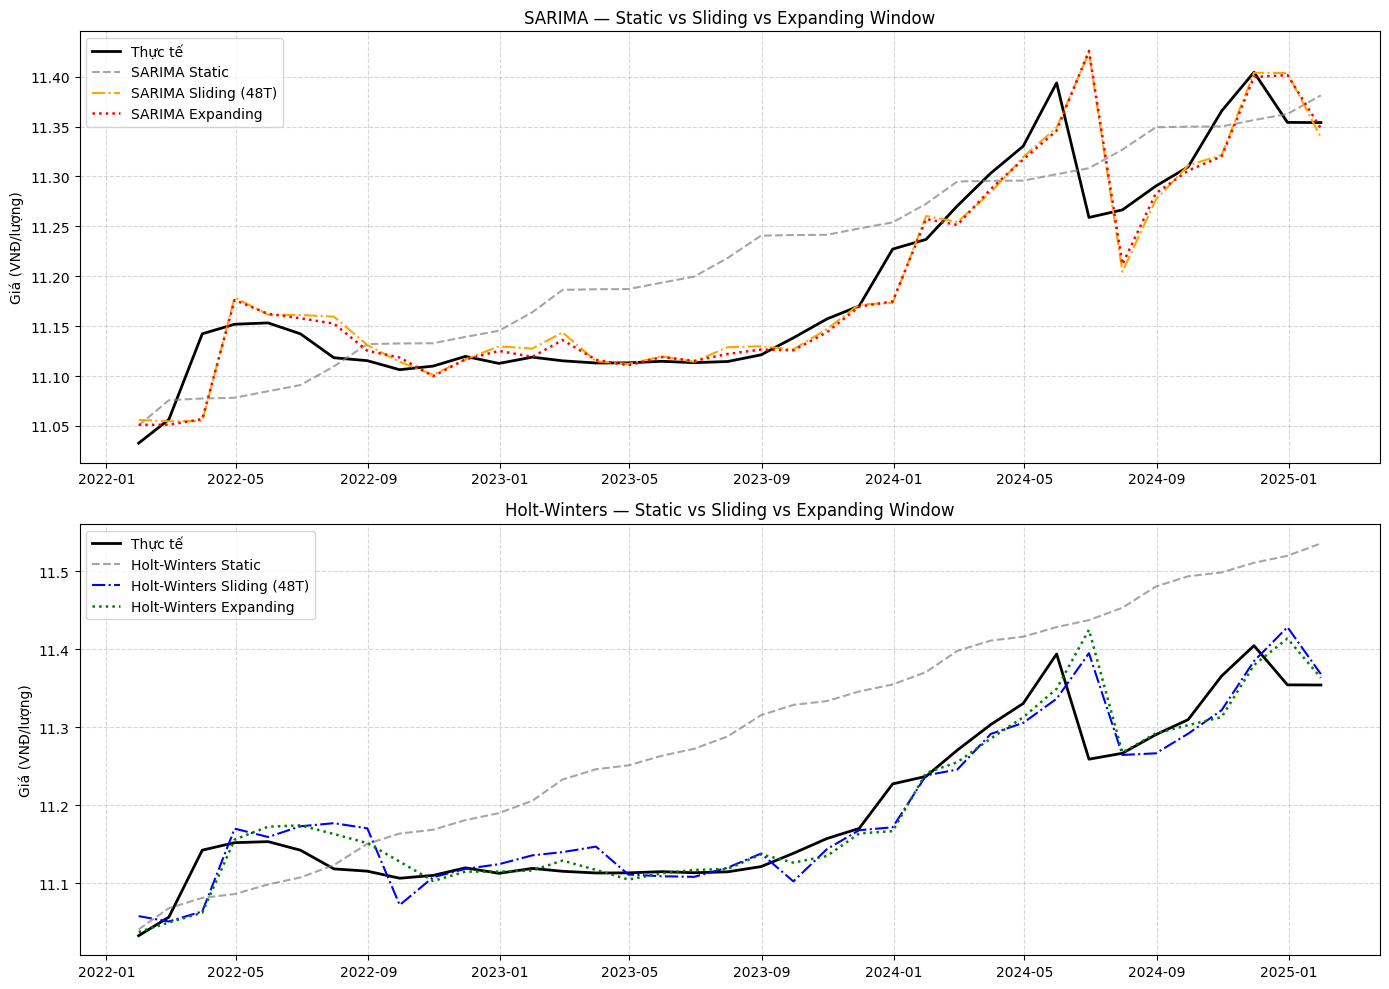

In [78]:
# ── Expanding Window — SARIMA và Holt-Winters ──────────────────────────────
print('Expanding Window đang chạy cho SARIMA và Holt-Winters...')
expanding_preds_sarima_ew = []
expanding_preds_hw_ew     = []

# Khởi tạo SARIMA trên toàn bộ tập train, sau đó append từng điểm (refit=False)
fitted_sarima_ew = SARIMAX(
    monthly_vals[:train_size_m],
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

for i in range(train_size_m, len(monthly_vals)):
    # SARIMA: forecast 1 bước, append điểm mới vào state (giữ nguyên tham số)
    expanding_preds_sarima_ew.append(fitted_sarima_ew.forecast(steps=1)[0])
    fitted_sarima_ew = fitted_sarima_ew.append([monthly_vals[i]], refit=False)

    # Holt-Winters: refit trên cửa sổ mở rộng từ đầu đến hiện tại
    hw_ew = ExponentialSmoothing(
        monthly_vals[:i],
        trend='add',
        seasonal='add',
        seasonal_periods=12,
        initialization_method='estimated'
    ).fit()
    expanding_preds_hw_ew.append(float(hw_ew.forecast(steps=1)[0]))

    if (i - train_size_m) % 10 == 0:
        print(f'   Bước {i - train_size_m}/{len(monthly_vals) - train_size_m}')

print('   Xong ✅\n')

# ── Metrics ─────────────────────────────────────────────────────────────────
mae_sarima_ew, rmse_sarima_ew, mape_sarima_ew = get_metrics(actual_m, expanding_preds_sarima_ew)
mae_hw_ew,     rmse_hw_ew,     mape_hw_ew     = get_metrics(actual_m, expanding_preds_hw_ew)

# ── Bảng so sánh: Static / Sliding / Expanding ──────────────────────────────
print('='*72)
print(f'{"Mô hình":<35} {"MAE":>10} {"RMSE":>10} {"MAPE":>8}')
print('='*72)
print(f'{"SARIMA Static":<35} {mae_sarima_st:>10,.0f} {rmse_sarima_st:>10,.0f} {mape_sarima_st:>7.2f}%')
print(f'{"SARIMA Sliding ("+str(window_size_m)+"T)":<35} {mae_sarima_sw:>10,.0f} {rmse_sarima_sw:>10,.0f} {mape_sarima_sw:>7.2f}%')
print(f'{"SARIMA Expanding":<35} {mae_sarima_ew:>10,.0f} {rmse_sarima_ew:>10,.0f} {mape_sarima_ew:>7.2f}%')
print('-'*72)
print(f'{"Holt-Winters Static":<35} {mae_hw_st:>10,.0f} {rmse_hw_st:>10,.0f} {mape_hw_st:>7.2f}%')
print(f'{"Holt-Winters Sliding ("+str(window_size_m)+"T)":<35} {mae_hw_sw:>10,.0f} {rmse_hw_sw:>10,.0f} {mape_hw_sw:>7.2f}%')
print(f'{"Holt-Winters Expanding":<35} {mae_hw_ew:>10,.0f} {rmse_hw_ew:>10,.0f} {mape_hw_ew:>7.2f}%')
print('='*72)

# ── Biểu đồ so sánh ba chiến lược ───────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(test_m.index, actual_m,                   label='Thực tế',                              color='black',  linewidth=2)
axes[0].plot(test_m.index, np.array(sarima_forecast),  label='SARIMA Static',                        color='gray',   linestyle='--', alpha=0.7)
axes[0].plot(test_m.index, sliding_preds_sarima_sw,    label=f'SARIMA Sliding ({window_size_m}T)',   color='orange', linestyle='-.')
axes[0].plot(test_m.index, expanding_preds_sarima_ew,  label='SARIMA Expanding',                     color='red',    linestyle=':',  linewidth=1.8)
axes[0].set_title('SARIMA — Static vs Sliding vs Expanding Window')
axes[0].set_ylabel('Giá (VNĐ/lượng)')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(test_m.index, actual_m,                   label='Thực tế',                               color='black', linewidth=2)
axes[1].plot(test_m.index, hw_forecast.values,         label='Holt-Winters Static',                   color='gray',  linestyle='--', alpha=0.7)
axes[1].plot(test_m.index, sliding_preds_hw_sw,        label=f'Holt-Winters Sliding ({window_size_m}T)', color='blue',  linestyle='-.')
axes[1].plot(test_m.index, expanding_preds_hw_ew,      label='Holt-Winters Expanding',                color='green', linestyle=':',  linewidth=1.8)
axes[1].set_title('Holt-Winters — Static vs Sliding vs Expanding Window')
axes[1].set_ylabel('Giá (VNĐ/lượng)')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

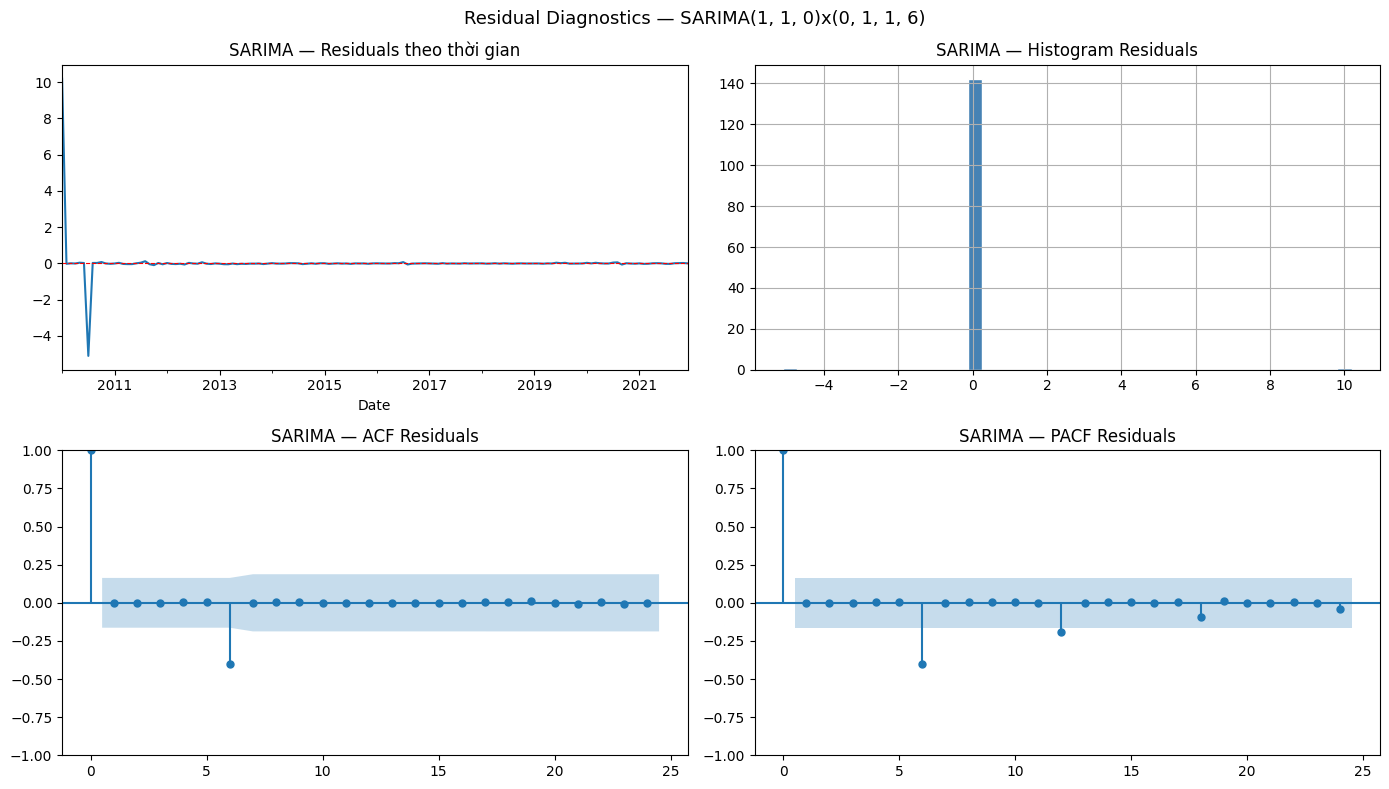

=== Ljung-Box — SARIMA ===
      lb_stat  lb_pvalue
10  24.256287   0.006948
20  24.281675   0.230305

→ Còn autocorrelation ⚠️


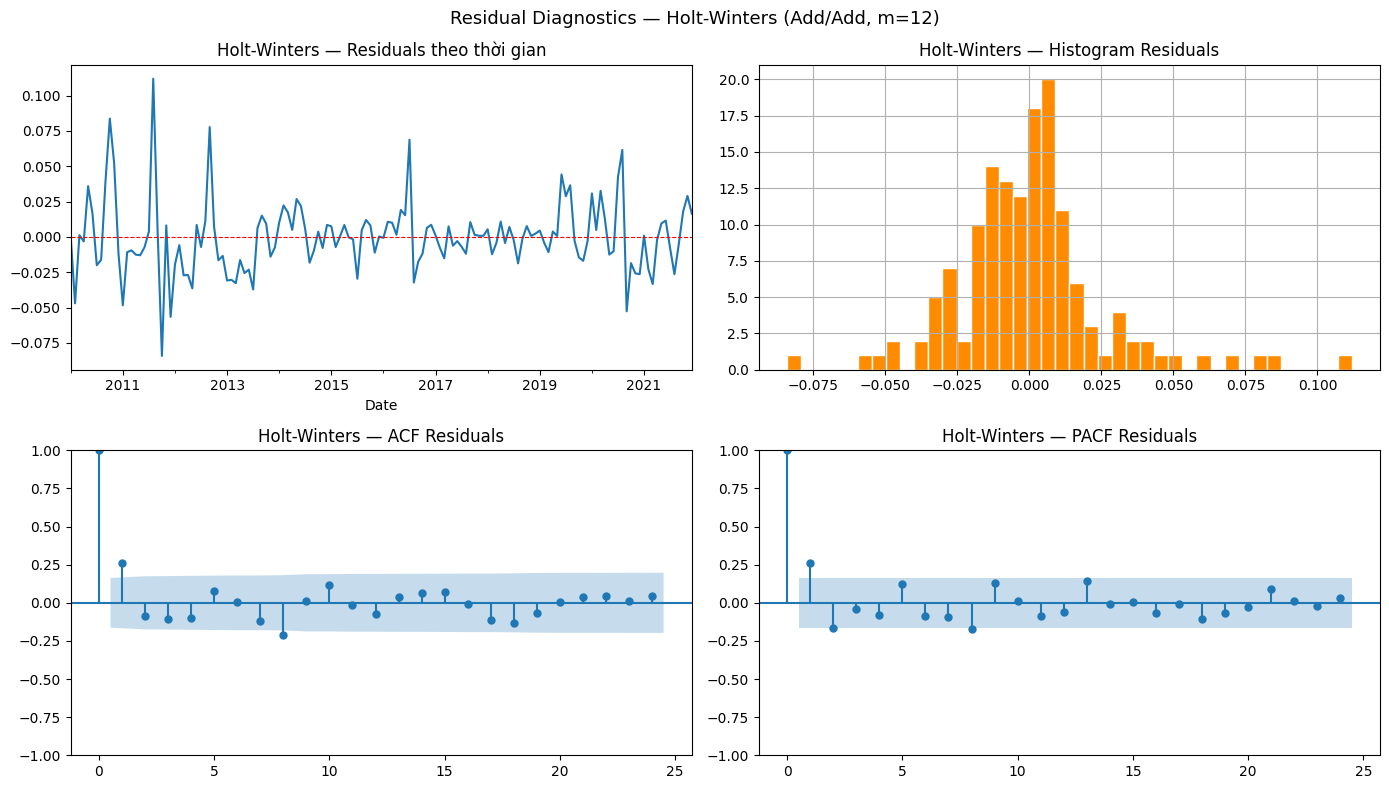

=== Ljung-Box — Holt-Winters ===
      lb_stat  lb_pvalue
10  26.178157   0.003508
20  34.745106   0.021505

→ Còn autocorrelation ⚠️


In [79]:
# ── Residual Diagnostics — SARIMA ────────────────────────────────────────
sarima_resid = pd.Series(sarima_model.resid(), index=train_m.index)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sarima_resid.plot(ax=axes[0,0], title='SARIMA — Residuals theo thời gian')
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=0.8)
sarima_resid.hist(bins=40, ax=axes[0,1], color='steelblue', edgecolor='white')
axes[0,1].set_title('SARIMA — Histogram Residuals')
plot_acf(sarima_resid,  ax=axes[1,0], lags=24, title='SARIMA — ACF Residuals')
plot_pacf(sarima_resid, ax=axes[1,1], lags=24, title='SARIMA — PACF Residuals')
plt.suptitle(f'Residual Diagnostics — SARIMA{sarima_order}x{sarima_seasonal_order}', fontsize=13)
plt.tight_layout(); plt.show()

lb_s = acorr_ljungbox(sarima_resid, lags=[10, 20], return_df=True)
print('=== Ljung-Box — SARIMA ===')
print(lb_s.to_string())
print(f'\n→ {"White noise ✅" if (lb_s["lb_pvalue"] > 0.05).all() else "Còn autocorrelation ⚠️"}')

# ── Residual Diagnostics — Holt-Winters ──────────────────────────────────
hw_resid = pd.Series(hw_model.resid.values, index=train_m.index)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
hw_resid.plot(ax=axes[0,0], title='Holt-Winters — Residuals theo thời gian')
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=0.8)
hw_resid.hist(bins=40, ax=axes[0,1], color='darkorange', edgecolor='white')
axes[0,1].set_title('Holt-Winters — Histogram Residuals')
plot_acf(hw_resid,  ax=axes[1,0], lags=24, title='Holt-Winters — ACF Residuals')
plot_pacf(hw_resid, ax=axes[1,1], lags=24, title='Holt-Winters — PACF Residuals')
plt.suptitle('Residual Diagnostics — Holt-Winters (Add/Add, m=12)', fontsize=13)
plt.tight_layout(); plt.show()

lb_h = acorr_ljungbox(hw_resid, lags=[10, 20], return_df=True)
print('=== Ljung-Box — Holt-Winters ===')
print(lb_h.to_string())
print(f'\n→ {"White noise ✅" if (lb_h["lb_pvalue"] > 0.05).all() else "Còn autocorrelation ⚠️"}')
